# Co-appearance of works in manuscripts — French vs German

## Sensitivity analysis: excluding the Ambraser Heldenbuch

This notebook is a **copy** of `01-networks.ipynb` with one change: every witness from the **Ambraser Heldenbuch** (Wien, ÖNB, *Cod. Ser. nova 2663*, `manuscript_id` 58329; completed 1504–1517) is dropped from the German linkage **before** the graph is built. French data are untouched. Figures are written to `docs/figures/no_ambras/`.

The concern is that this late multi-text codex alone joins Heldendichtung with Arthurian Britain material (Erec, Iwein, Titurel, Mantel, …) and could inflate cross-matiere co-appearance. Re-running the full pipeline here checks whether the main results depend on that single book.

Two works are linked whenever they share a manuscript; edge weight is the number of shared manuscripts. A work's date is its date of composition; a manuscript's date is that of the surviving copy. The two are never mixed.


In [1]:
import json
from pathlib import Path
from collections import Counter
from itertools import combinations
import numpy as np
import pandas as pd
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

plt.rcParams["font.family"] = "Roboto"
plt.rcParams["font.sans-serif"] = ["Roboto", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 150

INK, SUBTLE, GRID = "#111111", "#333333", "#e0e0e0"
LANGS = ["french", "german"]
FIG_DIR = "docs/figures/no_ambras"  # sensitivity-analysis figure output
Path(FIG_DIR).mkdir(parents=True, exist_ok=True)
MAT_ORDER_ALL = ["Britain", "France", "Rome", "Other"]
MAT_ORDER = ["Britain", "France", "Rome"]  # matieres retained for network/statistical analysis
MAT_COLORS = {"Britain": "#2E86AB", "France": "#E63946", "Rome": "#F4A261",
              "Other": "#2A9D8F", "Unknown": "#A0A0A0"}

def ensure_roboto():
    """Force Roboto for every subsequent matplotlib text artist.

    Registers the TTF files by path (reliable across cold font caches).
    """
    from pathlib import Path as _Path
    from matplotlib import font_manager as _fm
    _home = _Path.home() / "Library" / "Fonts"
    for _name in ("Roboto-Regular.ttf", "Roboto-Bold.ttf", "Roboto-Medium.ttf",
                  "Roboto-Italic.ttf", "Roboto-BoldItalic.ttf"):
        _p = _home / _name
        if _p.exists():
            try:
                _fm.fontManager.addfont(str(_p))
            except (ValueError, RuntimeError, OSError):
                pass
    plt.rcParams["font.family"] = "Roboto"
    plt.rcParams["font.sans-serif"] = ["Roboto", "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False

def force_roboto(fig):
    """Stamp Roboto onto every Text artist already on the figure (title, ticks, legend)."""
    ensure_roboto()
    import matplotlib.text as _mtext
    for t in fig.findobj(match=lambda x: isinstance(x, _mtext.Text)):
        t.set_fontfamily("Roboto")

def style_ax(ax, grid_axis="y"):
    ensure_roboto()
    ax.set_facecolor("white")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(SUBTLE); ax.spines[s].set_linewidth(0.8)
    ax.tick_params(colors=SUBTLE, labelsize=8, length=3, width=0.5)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, alpha=0.6, lw=0.5); ax.set_axisbelow(True)
    return ax


## Building the network

`load_linkage` reads and cleans a linkage file; `build_graph` adds one node per work and one edge per pair of works sharing a manuscript, after dropping fragmentary witnesses. Each edge carries two weights: `weight` is the shared-manuscript count (what the figures draw, and what the homophily models use), and `newman` is Newman's bipartite projection, \(1/(n-1)\) per manuscript of size \(n\). Communities are greedy modularity on `newman`, so a large anthology does not contribute a clique of count-1 edges; the drawn network is not rewritten.

In [2]:
# Ambraser Heldenbuch (ÖNB Cod. Ser. nova 2663): late (1504–1517) Heldenbuch
# excluded for this sensitivity run. Identified by manuscript_id (stable) and
# shelfmark (human-readable check).
EXCLUDE_MANUSCRIPT_IDS = {58329}
EXCLUDE_SHELFMARKS = {"Cod. Ser. nova 2663"}

def load_linkage(path):
    """Read a linkage file. Its values are already analysis-ready -- titles
    unquoted, status normalised, matiere resolved -- see docs/PREPROCESSING.md.
    Only the dtypes JSON cannot carry need restoring.

    Sensitivity: drop the Ambraser Heldenbuch before any graph is built."""
    with open(path, encoding="utf-8") as f:
        df = pd.DataFrame(json.load(f))
    df["manuscript_id"] = pd.to_numeric(df["manuscript_id"], errors="coerce").astype("Int64")
    # midpoint of the temporal range
    df["date_mid"] = ((pd.to_numeric(df["date_start"], errors="coerce")
                       + pd.to_numeric(df["date_end"], errors="coerce")) / 2).round()
    before = len(df)
    drop = df["manuscript_id"].isin(EXCLUDE_MANUSCRIPT_IDS)
    if "shelfmark" in df.columns:
        drop = drop | df["shelfmark"].isin(EXCLUDE_SHELFMARKS)
    n_drop = int(drop.sum())
    if n_drop:
        print(f"{path}: dropping Ambraser Heldenbuch — {n_drop} witness rows "
              f"(manuscript_id in {sorted(EXCLUDE_MANUSCRIPT_IDS)})")
        df = df.loc[~drop].copy()
    elif "german" in str(path):
        print(f"{path}: WARNING — Ambraser Heldenbuch not found to exclude")
    return df

def build_graph(df, weight="weight", exclude_status=("Fragmentary",)):
    if "status" in df and exclude_status:
        df = df[~df["status"].isin(exclude_status)].copy()

    G = nx.Graph()
    for wid, g in df.groupby("work_id", dropna=True):
        G.add_node(g.iloc[0]["work"], work_id=int(wid))
    for _, g in df.dropna(subset=["manuscript_id"]).groupby("manuscript_id"):
        works = sorted(g["work"].dropna().unique())
        n = len(works)
        if n < 2:
            continue
        # Newman 2001 projection: a manuscript of n works contributes 1/(n-1) to
        # each pair, so total weight from that book is n/2 rather than n(n-1)/2.
        newman_inc = 1.0 / (n - 1)
        for a, b in combinations(works, 2):
            if G.has_edge(a, b):
                G[a][b][weight] += 1
                G[a][b]["newman"] += newman_inc
            else:
                G.add_edge(a, b, **{weight: 1, "newman": newman_inc})

    # n_mss = size of the work's surviving manuscript tradition, counted after the same
    # status filter as the edges. Distinct from degree, which counts co-appearing *works*:
    # a work can be copied often and still meet few partners, and in German it frequently is.
    mss = df.dropna(subset=["manuscript_id"]).groupby("work")["manuscript_id"].nunique()
    nx.set_node_attributes(G, {n: int(mss.get(n, 0)) for n in G.nodes()}, "n_mss")

    # Communities on Newman weights: the count `weight` is left for drawing and for
    # the homophily models. Isolates (no edges) still form singleton communities.
    comms = (greedy_modularity_communities(G, weight="newman")
             if G.number_of_edges() else [{n} for n in G.nodes()])
    nx.set_node_attributes(G, {n: i for i, c in enumerate(comms) for n in c}, "community")
    return G, df


## Loading both traditions and assigning matiere

`matiere` is already final in `{lang}_works.xlsx` -- resolved from the storyverse hierarchy, aliased, and with any manual corrections folded in during preprocessing (see `docs/PREPROCESSING.md`, step 9). No alias/override logic is needed here any more: `assign_matiere` just reads the column. `load_all` builds both graphs and returns the graphs, the filtered linkage tables, the works metadata, and the raw (pre-status-filter) linkage tables -- the latter needed below for manuscript preservation states.


In [3]:
def assign_matiere(G, w, id_col="work_id", mat_col="matiere"):
    """matiere is final in the works file: one category per work, already
    aliased and corrected (see docs/PREPROCESSING.md). Nothing is remapped
    here -- this notebook only reads."""
    mm = {int(r[id_col]): r[mat_col] for _, r in w.iterrows()}
    nx.set_node_attributes(G, {n: mm.get(G.nodes[n].get("work_id"), "Unknown") for n in G.nodes()}, "matiere")

def tag_heldenepik(G, w, id_col="work_id", flag_col="is_heldenepik"):
    """Tag every node with is_heldenepik (bool) and mat5 (= matiere, but with
    Heldendichtung carved out of Other for flagged works). Language-agnostic: if the
    works file has no is_heldenepik column (e.g. French), mat5 simply mirrors matiere
    and nothing is flagged. Doing this at load time makes the Heldendichtung labelling
    available to the matiere-distribution figure below, not only to the German-specific
    split analysis much further down."""
    # pd.notna guard: a missing flag must read as False, not as bool(nan) == True
    flag = ({int(r[id_col]): bool(r[flag_col]) and pd.notna(r[flag_col])
             for _, r in w.iterrows()} if flag_col in w.columns else {})
    for n in G.nodes():
        h = flag.get(G.nodes[n].get("work_id"), False)
        m = G.nodes[n]["matiere"]
        G.nodes[n]["is_heldenepik"] = h
        G.nodes[n]["mat5"] = "Heldendichtung" if (h and m == "Other") else m

def load_all(langs, data="data"):
    graphs, links, works, raw = {}, {}, {}, {}
    for l in langs:
        raw_df = load_linkage(f"{data}/{l}_linkage.json")
        G, df = build_graph(raw_df)
        w = pd.read_excel(f"{data}/{l}_works.xlsx")
        # midpoint of the temporal range
        w["date_mid"] = ((pd.to_numeric(w["date_start"], errors="coerce")
                          + pd.to_numeric(w["date_end"], errors="coerce")) / 2).round()
        assign_matiere(G, w)
        tag_heldenepik(G, w)
        graphs[l], links[l], works[l], raw[l] = G, df, w, raw_df
    return graphs, links, works, raw

graphs, links, works, raw = load_all(LANGS)


data/german_linkage.json: dropping Ambraser Heldenbuch — 11 witness rows (manuscript_id in [58329])


In [4]:
# Confirm Ambraser Heldenbuch is absent from the loaded German tables
_ambras_raw = raw["german"]["manuscript_id"].isin(EXCLUDE_MANUSCRIPT_IDS).sum()
_ambras_links = links["german"]["manuscript_id"].isin(EXCLUDE_MANUSCRIPT_IDS).sum()
print(f"German raw rows with Ambras ms id: {_ambras_raw} (expect 0)")
print(f"German filtered-link rows with Ambras ms id: {_ambras_links} (expect 0)")
print(f"German graph: {graphs['german'].number_of_nodes()} nodes, "
      f"{graphs['german'].number_of_edges()} edges "
      f"(compare to main notebook once both are run)")


German raw rows with Ambras ms id: 0 (expect 0)
German filtered-link rows with Ambras ms id: 0 (expect 0)
German graph: 114 nodes, 141 edges (compare to main notebook once both are run)


## Descriptive comparison of the two networks

How do the two transmission networks compare in shape? Density and clustering fall naturally as a network grows, so the two columns are read qualitatively rather than as a strict ratio.

In [5]:
def network_summary(G, df, w):
    deg = dict(G.degree())
    wts = [d["weight"] for *_, d in G.edges(data=True)]
    comps = list(nx.connected_components(G))
    wpm = df.dropna(subset=["manuscript_id"]).groupby("manuscript_id")["work"].nunique()
    wits = df.groupby("work_id")["witness_id"].nunique()
    ms_date = df.dropna(subset=["manuscript_id"]).groupby("manuscript_id")["date_mid"].mean().dropna()
    work_date = pd.to_numeric(w.get("date_mid"), errors="coerce").dropna()
    return {
        "Works (nodes)": G.number_of_nodes(),
        "Co-occurring works": sum(d > 0 for d in deg.values()),
        "Manuscripts": int(df["manuscript_id"].nunique()),
        "Multi-work manuscripts": int((wpm > 1).sum()),
        "Witnesses": len(df),
        "Edges": G.number_of_edges(),
        "Density": round(nx.density(G), 4),
        "Avg degree": round(np.mean(list(deg.values())), 2),
        "Avg edge weight": round(np.mean(wts), 2) if wts else 0,
        "Max edge weight": max(wts) if wts else 0,
        "Components": len(comps),
        "Largest component": max((len(c) for c in comps), default=0),
        "Avg clustering": round(nx.average_clustering(G), 4),
        "Communities": len({G.nodes[n]["community"] for n in G.nodes()}),
        "Mean works / manuscript": round(wpm.mean(), 2),
        "Max works / manuscript": int(wpm.max()) if len(wpm) else 0,
        "Mean witnesses / work": round(wits.mean(), 2),
        "Median work date": round(work_date.median()) if len(work_date) else np.nan,
        "Median manuscript date": round(ms_date.median()) if len(ms_date) else np.nan,
    }

summary = pd.DataFrame({l: network_summary(graphs[l], links[l], works[l]) for l in LANGS})
summary.to_csv("data/network_comparison_no_ambras.csv")  # not the main notebook's file
summary

,french,german
Works (nodes),256.0000,114.0000
Co-occurring works,200.0000,75.0000
Manuscripts,911.0000,448.0000
Multi-work manuscripts,281.0000,104.0000
Witnesses,1616.0000,596.0000
Edges,907.0000,141.0000
Density,0.0278,0.0219
Avg degree,7.0900,2.4700
Avg edge weight,2.2100,1.6400
Max edge weight,36.0000,10.0000


**Table 1.** Structural comparison of the French and German co-appearance networks: counts of works, manuscripts and links, with density, degree, clustering, fragmentation and anthology size. *Communities* is greedy modularity on Newman projection weights (see the network-building cell), not on the shared-manuscript counts the figures draw.

## Distributions behind the summary

Works per manuscript, witnesses per work and edge weight are right-skewed and shown on box-and-jitter panels. Manuscript preservation state (fragmentary, complete, defective, …) is categorical and shown as a grouped-bar panel instead.

Bonferroni-corrected alpha (7 tests): 0.00714


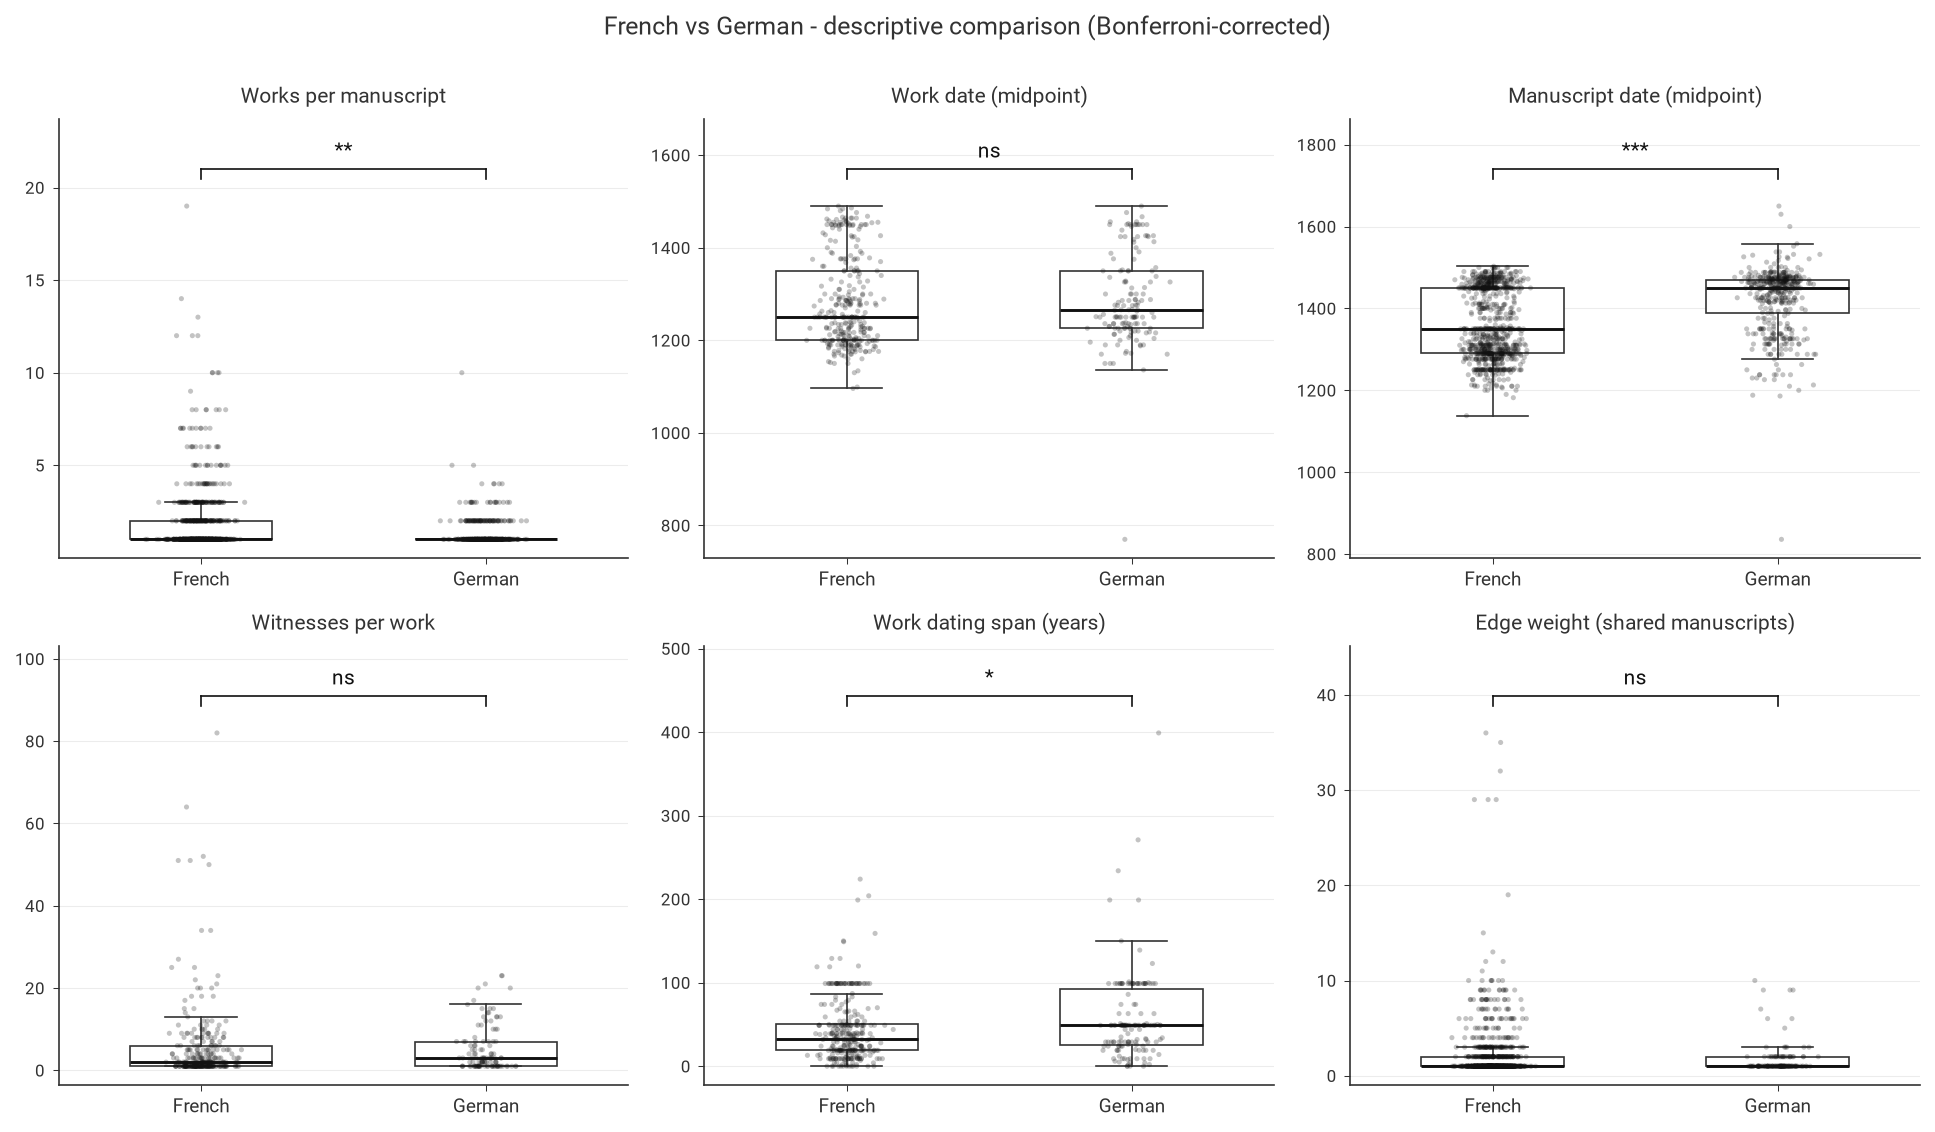

,panel,statistic,p_value,p_corrected_threshold,sig
0,Works per manuscript,224478.5,1.526084e-04,0.007143,**
1,Work date (midpoint),20058.0,7.530689e-02,0.007143,ns
2,Manuscript date (midpoint),120056.5,2.743250e-34,0.007143,***
3,Witnesses per work,15190.0,1.054429e-01,0.007143,ns
4,Work dating span (years),18024.5,8.180189e-04,0.007143,*
5,Edge weight (shared manuscripts),68385.0,1.065627e-01,0.007143,ns


In [6]:
from scipy.stats import mannwhitneyu

def num(df, c): return pd.to_numeric(df.get(c), errors="coerce").dropna()
def works_per_ms(df): return df.dropna(subset=["manuscript_id"]).groupby("manuscript_id")["work"].nunique()
def ms_dates(df): return df.dropna(subset=["manuscript_id"]).groupby("manuscript_id")["date_mid"].mean().dropna()
def wits_per_work(df): return df.groupby("work_id")["witness_id"].nunique()
def edge_weights(G): return pd.Series([d["weight"] for *_, d in G.edges(data=True)])
def work_span(df):
    s, e = num(df, "date_start"), num(df, "date_end")
    j = pd.concat([s, e], axis=1).dropna()
    return j.iloc[:, 1] - j.iloc[:, 0]

def sig_stars(p, alpha=0.05):
    if p < alpha / 1000:      # keep roughly the same visual banding, scaled to corrected alpha
        return "***"
    elif p < alpha / 10:
        return "**"
    elif p < alpha:
        return "*"
    else:
        return "ns"

panels = [
    ("Works per manuscript", lambda l: works_per_ms(links[l])),
    ("Work date (midpoint)", lambda l: num(works[l], "date_mid")),
    ("Manuscript date (midpoint)", lambda l: ms_dates(links[l])),
    ("Witnesses per work", lambda l: wits_per_work(links[l])),
    ("Work dating span (years)", lambda l: work_span(works[l])),
    ("Edge weight (shared manuscripts)", lambda l: edge_weights(graphs[l])),
]

n_tests = len(panels) + 1  # +1 for the manuscript-status chi-square test (next cell)
alpha_corrected = 0.05 / n_tests  # Bonferroni-corrected significance threshold, shared across both cells
print(f"Bonferroni-corrected alpha ({n_tests} tests): {alpha_corrected:.5f}")

ensure_roboto()
rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
results = []
for ax, (title, getter) in zip(axes.ravel(), panels):
    data = [pd.Series(getter(l)).dropna().astype(float).values for l in LANGS]

    bp = ax.boxplot(data, patch_artist=True, widths=0.5, showfliers=False,
                    medianprops=dict(color=INK, lw=1.4),
                    whiskerprops=dict(color=SUBTLE, lw=0.8),
                    capprops=dict(color=SUBTLE, lw=0.8),
                    boxprops=dict(color=SUBTLE, lw=0.8))
    for patch in bp["boxes"]:
        patch.set_facecolor("white")
    for i, d in enumerate(data, 1):
        ax.scatter(rng.normal(i, 0.05, len(d)), d, s=6, color=INK, alpha=0.25, edgecolors="none", zorder=3)

    # --- Mann-Whitney U test + Bonferroni-corrected significance bracket ---
    statistic, p_value = mannwhitneyu(data[0], data[1], alternative="two-sided")
    sig_text = sig_stars(p_value, alpha=alpha_corrected)
    results.append(dict(panel=title, statistic=statistic, p_value=p_value,
                        p_corrected_threshold=alpha_corrected, sig=sig_text))

    y_max = max(d.max() for d in data)
    y_min = min(d.min() for d in data)
    y_range = y_max - y_min if y_max > y_min else y_max
    bracket_height = y_max + y_range * 0.08
    line_height = bracket_height + y_range * 0.03

    ax.plot([1, 1], [bracket_height, line_height], color=INK, linewidth=0.8)
    ax.plot([2, 2], [bracket_height, line_height], color=INK, linewidth=0.8)
    ax.plot([1, 2], [line_height, line_height], color=INK, linewidth=0.8)
    ax.text(1.5, line_height + y_range * 0.02, sig_text,
            ha="center", va="bottom", fontsize=10, color=INK)
    ax.set_ylim(top=line_height + y_range * 0.15)

    style_ax(ax)
    ax.set_xticks([1, 2]); ax.set_xticklabels([l.capitalize() for l in LANGS], fontsize=9)
    ax.set_title(title, fontsize=10, color=SUBTLE, pad=8)

fig.suptitle("French vs German - descriptive comparison (Bonferroni-corrected)", fontsize=12, color=SUBTLE, y=1.0)
plt.tight_layout()
force_roboto(fig)
plt.savefig(f"{FIG_DIR}/fig1_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

results_df = pd.DataFrame(results)
results_df


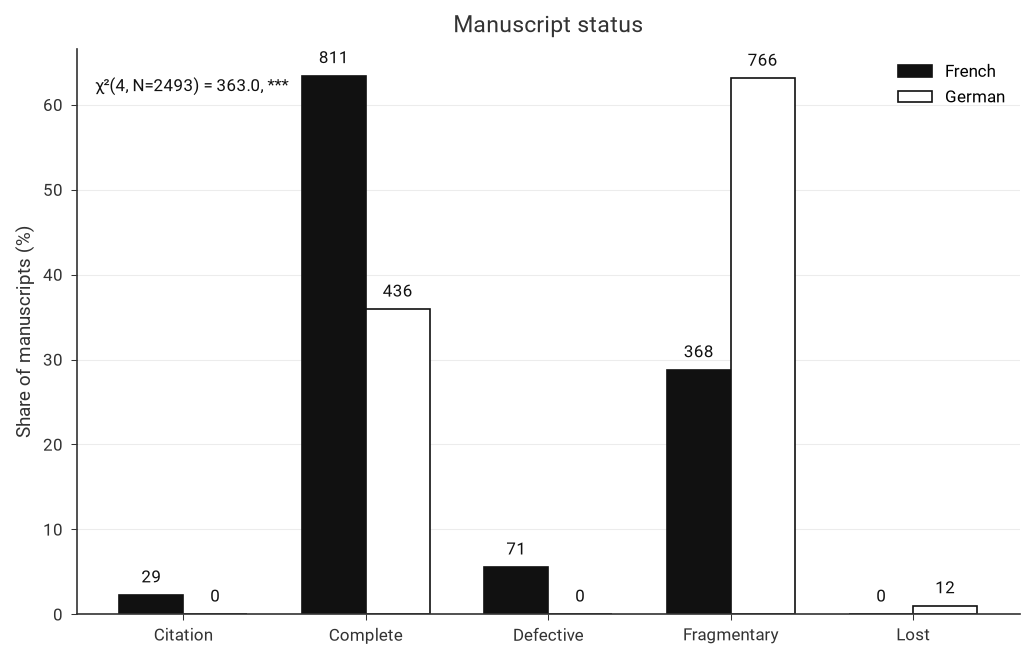

,panel,statistic,p_value,p_corrected_threshold,sig
0,Works per manuscript,224478.500000,1.526084e-04,0.007143,**
1,Work date (midpoint),20058.000000,7.530689e-02,0.007143,ns
2,Manuscript date (midpoint),120056.500000,2.743250e-34,0.007143,***
3,Witnesses per work,15190.000000,1.054429e-01,0.007143,ns
4,Work dating span (years),18024.500000,8.180189e-04,0.007143,*
5,Edge weight (shared manuscripts),68385.000000,1.065627e-01,0.007143,ns
6,Manuscript status,363.008745,2.722236e-77,0.007143,***


In [7]:
from scipy.stats import chi2_contingency

def status_counts(df):
    return df.dropna(subset=["manuscript_id"]).groupby("manuscript_id")["status"].first().value_counts()

counts = {l: status_counts(raw[l]) for l in LANGS}
cats = sorted(set().union(*[c.index for c in counts.values()]))
table = pd.DataFrame({l: counts[l].reindex(cats, fill_value=0) for l in LANGS})
pct = table / table.sum() * 100

# Chi-square test of independence between preservation status and language -- this was
# chi-square of independence between preservation status and language;
# alpha_corrected (previous cell) accounts for this as the extra test alongside the boxplots.
chi2_stat, chi2_p, chi2_dof, _ = chi2_contingency(table)
chi2_sig = sig_stars(chi2_p, alpha=alpha_corrected)
results_df = pd.concat([results_df, pd.DataFrame([{
    "panel": "Manuscript status", "statistic": chi2_stat, "p_value": chi2_p,
    "p_corrected_threshold": alpha_corrected, "sig": chi2_sig,
}])], ignore_index=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(cats)); bw = 0.35
for i, l in enumerate(LANGS):
    bars = ax.bar(x + (i - 0.5) * bw, pct[l], width=bw,
                  facecolor="white" if i else INK, edgecolor=INK, lw=0.8, label=l.capitalize())
    for rect, n in zip(bars, table[l]):
        ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 1, int(n),
                ha="center", va="bottom", fontsize=8, color=INK)

ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=9)
ax.set_ylabel("Share of manuscripts (%)", fontsize=9, color=SUBTLE)
ax.legend(frameon=False, fontsize=8, loc="upper right")
style_ax(ax)
ax.set_title("Manuscript status", fontsize=11, color=SUBTLE, pad=8)
ax.text(0.02, 0.95, f"\u03c7\u00b2({chi2_dof}, N={int(table.values.sum())}) = {chi2_stat:.1f}, {chi2_sig}",
        transform=ax.transAxes, ha="left", va="top", fontsize=8, color=INK)
plt.tight_layout()
plt.show()

results_df


**Figure 1.** Descriptive distributions for the two traditions. Boxes show median and IQR, points are individual works/manuscripts (jittered). Annotations give two-sided Mann-Whitney U tests, Bonferroni-corrected jointly with the manuscript-status chi-square shown separately below (not exported). Exact statistics are in `results_df`.


## Matiere distribution by language

Share of works assigned to each matiere, all categories including Other/Unknown, for context before the matiere-restricted analyses below.
Two optional sub-bars carve *Other*: German *Heldendichtung* (purple; from the `is_heldenepik`/`mat5` tags added at load time) and French works whose composition midpoint falls after 1300 (dark teal), testing whether post-Bodel residue inflates French *Other*. Work dates only.


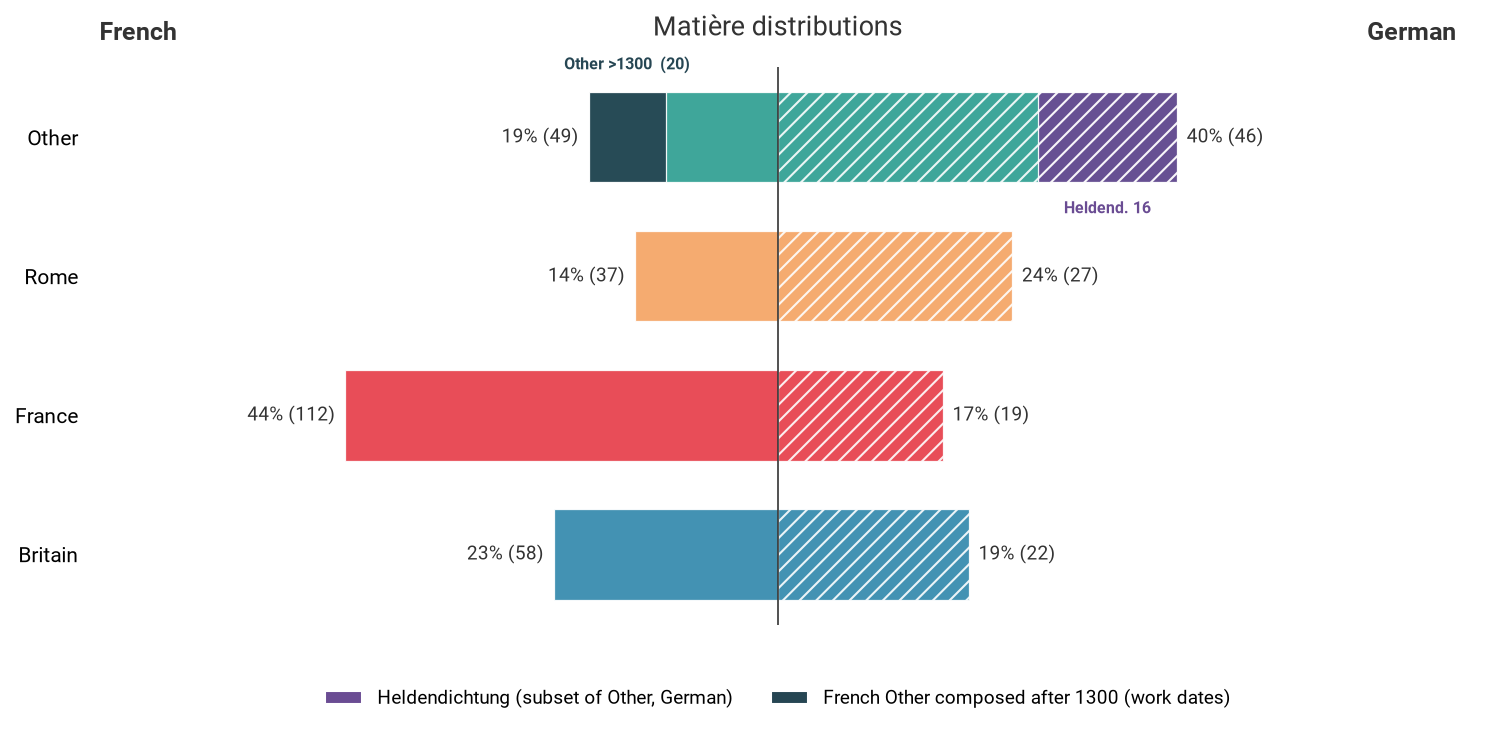

French Other on graph: 49 works; composed after 1300: 20


In [8]:
from matplotlib.patches import Patch

HELDEN_COLOR = "#6A4C93"   # matches the Heldendichtung colour used in the network figures
BODEL_CUTOFF = 1300
OTHER_AFTER_BODEL_COLOR = "#264653"  # dark teal: post-horizon French Other (Other-family, not Rome/Heldendichtung)

def _is_german(lang):
    return lang.lower().startswith("german") or lang.lower() == "de"

def _is_french(lang):
    return lang.lower().startswith("french") or lang.lower() == "fr"

def matiere_distribution(G, order=MAT_ORDER_ALL):
    counts = Counter(nx.get_node_attributes(G, "matiere").values())
    total = sum(counts.values())
    pct = pd.Series({c: counts.get(c, 0) / total * 100 for c in order}, index=order)
    raw = pd.Series({c: counts.get(c, 0) for c in order}, index=order)
    return pct, raw

def heldendichtung_count(G):
    """Works that are Heldendichtung (a subset of Other). Prefers mat5, falls
    back to an is_heldenepik flag among Other-labelled works."""
    m5 = nx.get_node_attributes(G, "mat5")
    if m5:
        return sum(v == "Heldendichtung" for v in m5.values())
    flag = nx.get_node_attributes(G, "is_heldenepik")
    mat = nx.get_node_attributes(G, "matiere")
    return sum(bool(flag.get(n)) and mat.get(n) == "Other" for n in G.nodes())

def other_after_bodel_count(G, works_df, cutoff=BODEL_CUTOFF):
    """Graph nodes labelled Other with composition date_mid strictly after cutoff."""
    mat = nx.get_node_attributes(G, "matiere")
    wids = nx.get_node_attributes(G, "work_id")
    dm = {int(r.work_id): float(r.date_mid) for _, r in works_df.iterrows()
          if pd.notna(r.get("work_id")) and pd.notna(r.get("date_mid"))}
    return sum(
        1 for n in G.nodes()
        if mat.get(n) == "Other"
        and (wid := wids.get(n)) is not None
        and dm.get(int(wid), -np.inf) > cutoff
    )

def plot_matiere_comparison(graphs, works, langs, cutoff=BODEL_CUTOFF, savepath=None):
    """Matiere bar chart with German Heldendichtung and French Other after Bodel's horizon."""
    l1, l2 = langs
    pct1, raw1 = matiere_distribution(graphs[l1])
    pct2, raw2 = matiere_distribution(graphs[l2])
    cats = pct1.index.tolist(); y = np.arange(len(cats))
    totals = {l1: raw1.sum(), l2: raw2.sum()}

    ensure_roboto()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(y, -pct1.values, color=[MAT_COLORS[c] for c in cats],
            edgecolor="white", linewidth=0.6, height=0.65, alpha=0.9)
    ax.barh(y, pct2.values, color=[MAT_COLORS[c] for c in cats],
            edgecolor="white", linewidth=0.6, height=0.65, alpha=0.9, hatch="///")

    legend_handles = []
    # German Heldendichtung sub-bar at the tip of Other
    for lang, sign, hatch in [(l1, -1, None), (l2, +1, "///")]:
        if not _is_german(lang) or "Other" not in cats:
            continue
        n_h = heldendichtung_count(graphs[lang])
        if n_h == 0:
            continue
        yi = cats.index("Other")
        other_pct = (pct1 if sign < 0 else pct2)["Other"]
        helden_pct = n_h / totals[lang] * 100
        start, end = sign * (other_pct - helden_pct), sign * other_pct
        ax.barh(yi, abs(end - start), left=min(start, end), color=HELDEN_COLOR,
                edgecolor="white", linewidth=0.6, height=0.65, alpha=0.95, hatch=hatch)
        ax.text((start + end) / 2, yi - 0.46, f"Heldend. {n_h}", ha="center", va="top",
                fontsize=7.5, color=HELDEN_COLOR, fontweight="bold")
        legend_handles.append(Patch(facecolor=HELDEN_COLOR, edgecolor="white",
                                    label="Heldendichtung (subset of Other, German)"))

    # French Other sub-bar: works composed after Bodel's horizon
    for lang, sign, hatch in [(l1, -1, None), (l2, +1, "///")]:
        if not _is_french(lang) or "Other" not in cats:
            continue
        n_a = other_after_bodel_count(graphs[lang], works[lang], cutoff)
        if n_a == 0:
            continue
        yi = cats.index("Other")
        other_pct = (pct1 if sign < 0 else pct2)["Other"]
        after_pct = n_a / totals[lang] * 100
        start, end = sign * (other_pct - after_pct), sign * other_pct
        ax.barh(yi, abs(end - start), left=min(start, end), color=OTHER_AFTER_BODEL_COLOR,
                edgecolor="white", linewidth=0.6, height=0.65, alpha=0.95, hatch=hatch)
        ax.text((start + end) / 2, yi + 0.46, f"Other >{cutoff}  ({n_a})", ha="center", va="bottom",
                fontsize=7.5, color=OTHER_AFTER_BODEL_COLOR, fontweight="bold")
        legend_handles.append(Patch(facecolor=OTHER_AFTER_BODEL_COLOR, edgecolor="white",
                                    label=f"French Other composed after {cutoff} (work dates)"))

    for yi, p, n in zip(y, pct1.values, raw1.values):
        ax.text(-p - 1, yi, f"{p:.0f}% ({int(n)})", ha="right", va="center", fontsize=9, color="#333333")
    for yi, p, n in zip(y, pct2.values, raw2.values):
        ax.text(p + 1, yi, f"{p:.0f}% ({int(n)})", ha="left", va="center", fontsize=9, color="#333333")

    ax.set_yticks(y); ax.set_yticklabels(cats, fontsize=10)
    ax.tick_params(axis="y", length=0)
    ax.set_xticks([]); ax.axvline(0, color="#333333", linewidth=0.8)

    xmax = max(pct1.max(), pct2.max()) * 1.6
    ax.set_xlim(-xmax, xmax)
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

    ax.text(-xmax * 0.98, len(cats) - 0.3, l1.capitalize(), fontsize=12, fontweight="bold", color="#333333", ha="left")
    ax.text(xmax * 0.98, len(cats) - 0.3, l2.capitalize(), fontsize=12, fontweight="bold", color="#333333", ha="right")

    if legend_handles:
        ax.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.18),
                  frameon=False, fontsize=9, ncol=2)

    ax.set_title("Matière distributions", fontsize=13, color="#333333", pad=15)
    plt.tight_layout()
    force_roboto(fig)
    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()

    n_fr = other_after_bodel_count(graphs["french"], works["french"], cutoff)
    n_other_fr = sum(1 for n in graphs["french"].nodes()
                     if graphs["french"].nodes[n].get("matiere") == "Other")
    print(f"French Other on graph: {n_other_fr} works; composed after {cutoff}: {n_fr}")

plot_matiere_comparison(
    graphs, works, LANGS,
    savepath=f"{FIG_DIR}/fig2_matiere_other_bodel_horizon.png",
)


**Figure 2.** Matiere distribution by language (% of co-occurring works). German *Heldendichtung* is carved from *Other* in purple; French *Other* works with composition midpoint after 1300 are carved in dark teal (not Heldendichtung), testing whether post-Bodel residue inflates French *Other*. Work dates only.


## Networks coloured by matiere

Node area tracks manuscript-tradition size (one scale for both panels); edge width and opacity track the shared-manuscript count; colour marks matiere, with Heldendichtung carved out of Other (purple) and residual Other in grey. If matiere shapes co-transmission, same-matiere nodes should gather rather than scatter. (Tables 2-3 below restrict to Britain/France/Rome for the quantitative comparison; the network figure itself keeps every co-occurring work.)


In [9]:
MIN_DEGREE = {"french": 1, "german": 1}

def restrict(G, order=MAT_ORDER):
    return G.subgraph([n for n in G.nodes() if G.nodes[n]["matiere"] in order]).copy()


french  works shown=200  mss/work mean= 7.25 median= 3.0 max= 94  degree mean= 9.07  mss per degree=0.80
german  works shown= 75  mss/work mean= 7.08 median= 5.0 max= 24  degree mean= 3.76  mss per degree=1.88


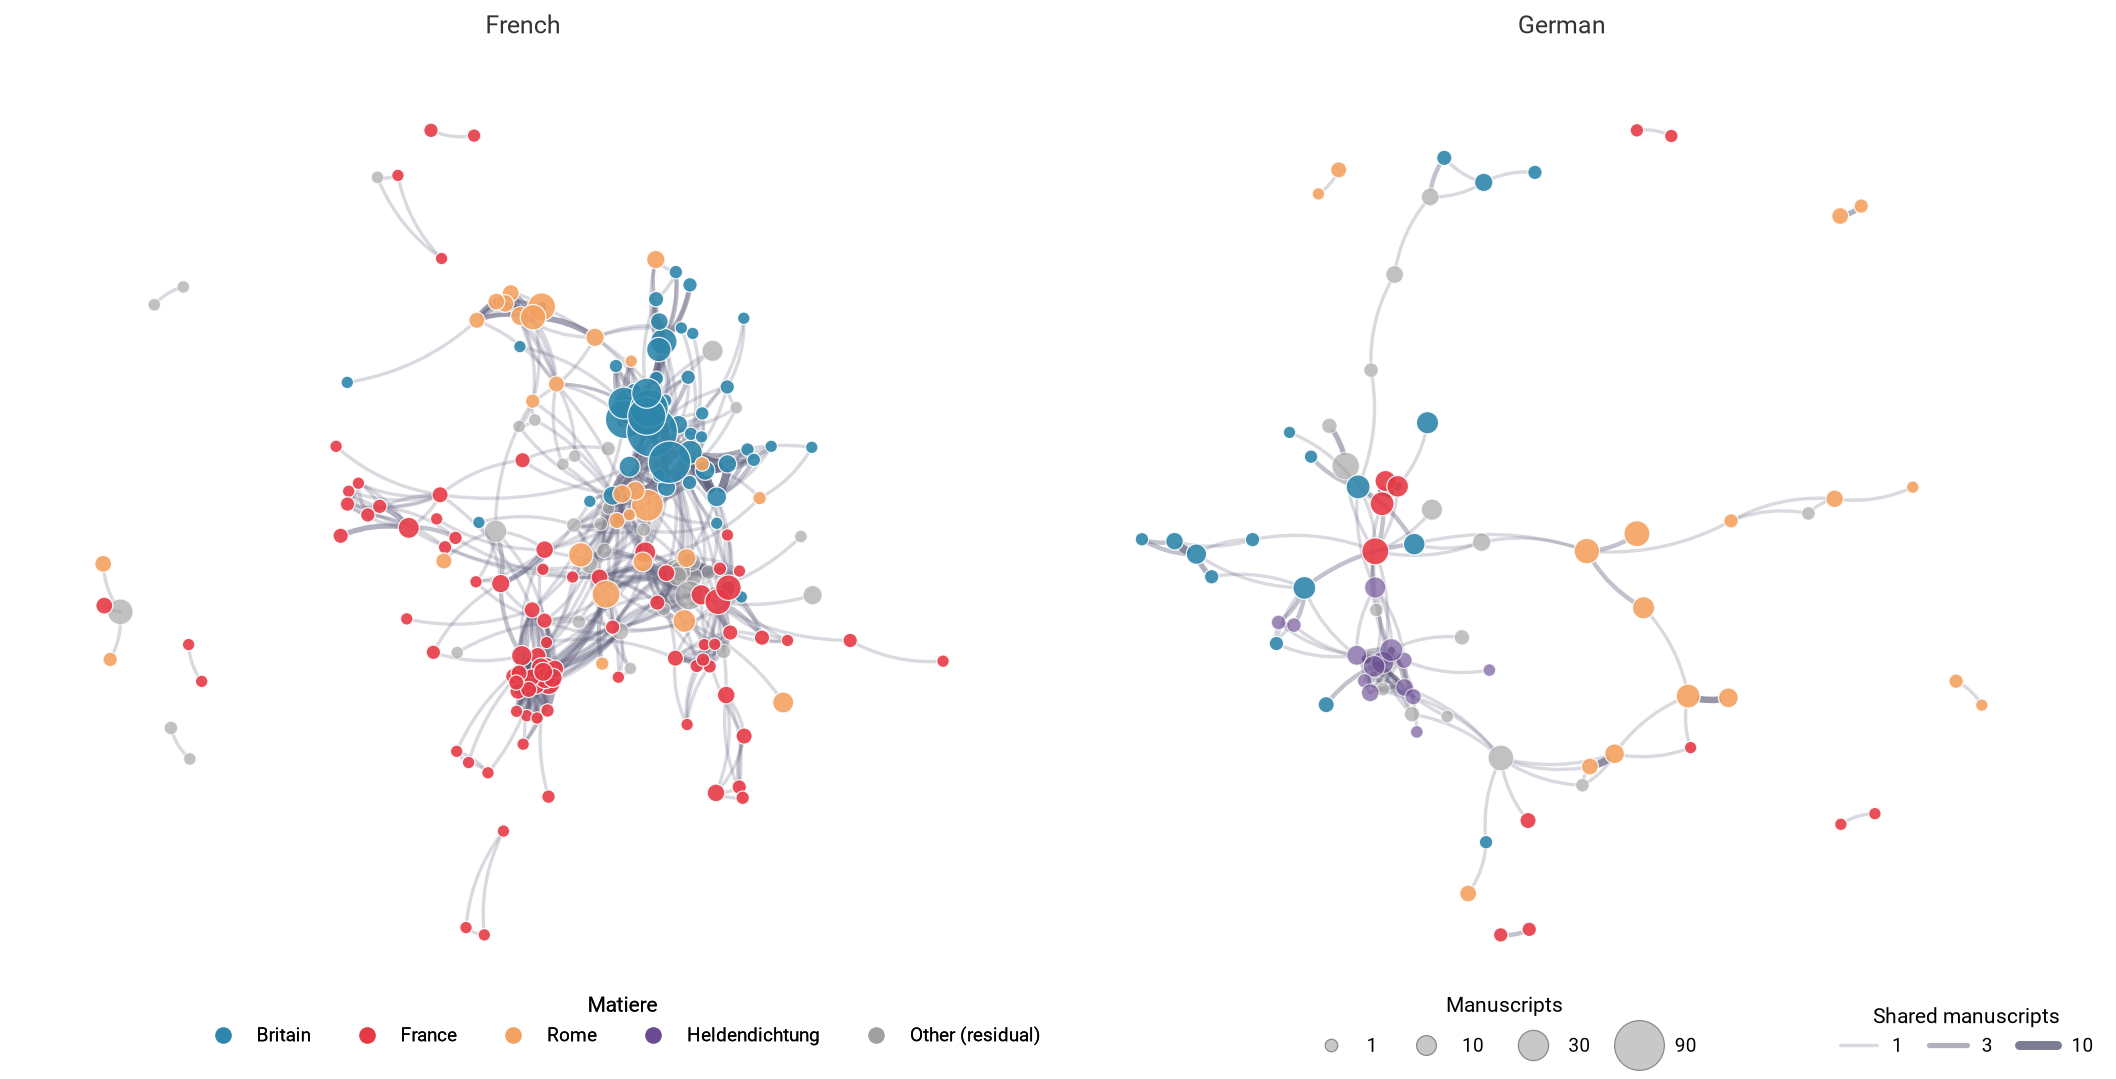

In [10]:
# Node area is proportional to n_mss (manuscript-tradition size), NOT to degree, and the
# same two constants are used for both panels so a circle means the same number of
# manuscripts in each. Degree is already carried by the edges; sizing by it too spent the
# node channel on information the figure showed twice, and made German works look small
# when what is actually small is their number of co-appearance partners, not their
# tradition. matplotlib's node_size is an area in pt^2, so a linear map keeps area -- the
# quantity the eye compares -- proportional to the manuscript count.
MSS_SIZE_BASE, MSS_SIZE_SCALE = 30.0, 6.0
MSS_LEGEND_VALUES = [1, 10, 30, 90]

def mss_node_size(H, nodes):
    return [MSS_SIZE_BASE + MSS_SIZE_SCALE * H.nodes[n].get("n_mss", 0) for n in nodes]


# Shared-manuscript count, same constants in every network figure (as node area).
# sqrt(width) so a weight-10 core is clearly heavier than the weight-1 hair without
# French's weight-36 edges filling the panel; alpha rises over the first few
# co-copies so repeated kernels (Willehalm–Arabel–Rennewart at 9–10) read as ink.
EDGE_INK = "#5C5C7A"
EDGE_LEGEND_VALUES = [1, 3, 10]


def _edge_width(w):
    return 0.35 + 1.25 * np.sqrt(float(w))


def _edge_alpha(w):
    return 0.05 + 0.82 * (1.0 - np.exp(-0.25 * float(w)))


def draw_weighted_edges(H, pos, ax, weight="weight", curvature=0.15, node_size=None,
                        zorder=1):
    """Draw edges with width and opacity from shared-manuscript count, faint first."""
    edges = list(H.edges())
    if not edges:
        return
    wts = np.array([H[u][v].get(weight, 1) for u, v in edges], dtype=float)
    order = np.argsort(wts)
    edges = [edges[i] for i in order]
    wts = wts[order]
    widths = [_edge_width(w) for w in wts]
    rgba = to_rgba(EDGE_INK)
    colors = [(rgba[0], rgba[1], rgba[2], _edge_alpha(w)) for w in wts]
    if node_size is None:
        node_size = mss_node_size(H, H.nodes())
    artists = nx.draw_networkx_edges(
        H, pos, ax=ax, edgelist=edges, width=widths, edge_color=colors, alpha=None,
        connectionstyle=f"arc3,rad={curvature}", arrows=True, arrowstyle="-",
        node_size=node_size, min_source_margin=0, min_target_margin=0,
    )
    if artists is None:
        return
    if not isinstance(artists, list):
        artists = [artists]
    for art, w in zip(artists, wts):
        art.set_zorder(zorder + 0.5 * min(float(w), 12) / 12)


def plot_network_with_other(ax, G, min_degree, seed=42, weight="weight", curvature=0.15,
                            attr="mat5"):
    H = G.copy()  # every node kept: Other, and Heldendichtung within it where flagged, stays visible
    if min_degree is not None:
        H = H.subgraph([n for n, d in H.degree() if d >= min_degree]).copy()
    pos = nx.spring_layout(H, k=1.0, iterations=300, weight=weight, seed=seed)

    draw_weighted_edges(H, pos, ax, weight=weight, curvature=curvature)
    # draw order: residual Other and Heldendichtung underneath, B/F/R on top and legible
    for cat in ["Other", "Heldendichtung", *MAT_ORDER]:
        ns = [n for n in H.nodes() if H.nodes[n][attr] == cat]
        if not ns:
            continue
        # residual Other is deliberately neutral grey so it recedes behind the argument
        color = {"Heldendichtung": HELDEN_COLOR, "Other": "#A0A0A0"}.get(cat) or MAT_COLORS[cat]
        alpha = 0.9 if cat in MAT_ORDER else 0.65
        nx.draw_networkx_nodes(H, pos, ax=ax, nodelist=ns, node_color=color,
                               node_size=mss_node_size(H, ns),
                               linewidths=0.6, edgecolors="white", alpha=alpha)
    ax.set_axis_off()
    return H, pos

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
# NETWORK_POS keeps this figure's coordinates. The community figures in the
# bottom-up section below are drawn on exactly these positions, so a work sits in
# the same place in both and the two colourings can be compared node for node.
shown, NETWORK_POS = {}, {}
for ax, l in zip(axes, LANGS):
    shown[l], NETWORK_POS[l] = plot_network_with_other(ax, graphs[l], MIN_DEGREE[l])
    ax.set_title(l.capitalize(), fontsize=12, color="#333333")

for l, H in shown.items():
    m = np.array([H.nodes[n]["n_mss"] for n in H.nodes()])
    d = np.array([H.degree(n) for n in H.nodes()])
    print(f"{l:7s} works shown={len(m):3d}  mss/work mean={m.mean():5.2f} median={np.median(m):4.1f} "
          f"max={m.max():3d}  degree mean={d.mean():5.2f}  mss per degree={m.mean()/d.mean():.2f}")

handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=MAT_COLORS[c],
                  markeredgecolor="white", markersize=9, label=c) for c in MAT_ORDER]
handles.append(Line2D([0], [0], marker="o", color="w", markerfacecolor=HELDEN_COLOR,
                      markeredgecolor="white", markersize=9, label="Heldendichtung"))
handles.append(Line2D([0], [0], marker="o", color="w", markerfacecolor="#A0A0A0",
                      markeredgecolor="white", markersize=9, label="Other (residual)"))
leg1 = fig.legend(handles=handles, title="Matiere", loc="lower center", ncol=5,
                  frameon=False, fontsize=9, bbox_to_anchor=(0.30, -0.02))

# size key, in the same units as the nodes themselves (markersize is a diameter in points,
# node_size an area in pt^2, hence the square root)
size_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor="#C8C8C8",
                       markeredgecolor="#8A8A8A", markeredgewidth=0.6,
                       markersize=np.sqrt(MSS_SIZE_BASE + MSS_SIZE_SCALE * v), label=str(v))
                for v in MSS_LEGEND_VALUES]
fig.legend(handles=size_handles, title="Manuscripts", loc="lower center", ncol=4,
           frameon=False, fontsize=9, labelspacing=1.1, handletextpad=0.9,
           columnspacing=1.6, bbox_to_anchor=(0.72, -0.03))
edge_handles = [Line2D([0], [0], color=(*to_rgba(EDGE_INK)[:3], _edge_alpha(v)),
                       lw=_edge_width(v), solid_capstyle="round", label=str(v))
                for v in EDGE_LEGEND_VALUES]
fig.legend(handles=edge_handles, title="Shared manuscripts", loc="lower center", ncol=3,
           frameon=False, fontsize=9, handletextpad=0.8, columnspacing=1.4,
           bbox_to_anchor=(0.94, -0.03))
fig.add_artist(leg1)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig3_with_other.png", dpi=200, bbox_inches="tight")
plt.show()


**Figure 3.** Co-appearance networks for French (left) and German (right), all
co-occurring works shown: Britain (blue), France (red), Rome (orange), Heldendichtung
(purple, a subset of Other -- German only) and the remaining residual
Other in grey. Edge width and opacity both track the shared-manuscript count (same
scale in both panels: a given weight looks the same on the left as on the right), so
a pair copied together many times — the Willehalm–Arabel–Rennewart kernel at 9–10
manuscripts — reads as a dark stroke and a one-off co-copy recedes. Both traditions
at degree ≥ 1.

**Node area ∝ the size of the work's surviving manuscript tradition, on one scale shared
by both panels**, so a circle of a given size means the same number of manuscripts on
either side. This replaces the earlier sizing by degree, which spent the node channel on
information the edges already carry and, more seriously, conflated two different things:
how often a work was copied, and how many other works it met. Those come apart sharply
between the traditions. Among the works shown, manuscript traditions are of comparable
size (German median 4, French 3; means 6.9 and 7.3), but German works have barely half
the co-appearance degree (4.7 against 9.1) -- about 1.45 manuscripts per unit of degree
against 0.80 for French. Sized by degree, substantial German works looked marginal;
sized by manuscript count they do not. Hartlieb's *Alexander* (21 manuscripts, degree 1)
and Rudolf von Ems's *Barlaam und Josaphat* (24 manuscripts, degree 3) are the clearest
cases: heavily copied, but rarely sharing a codex with anything else in the corpus.

The German picture is therefore not one of small traditions but of well-transmitted works
that travelled comparatively alone -- more often in single-work or narrowly composed
codices than in the large multi-text compilations that bind the French corpus together.
The very largest traditions remain French (*Lancelot* 94, *Tristan* 64), and the degree ≥ 1
filter drops 56 French and 39 German isolates; four of the French ones have ten or more
manuscripts (*Troie, prose 5*; *Perceforest*; *Artus de Bretagne*; *Mélusine*), whereas no
dropped German work does, so the filter understates French tradition size more than German.


## Does shared matiere drive co-appearance?

Restricted to Britain/France/Rome, as in Tables 2-3 throughout (the network figure above keeps every work, Other included). `matiere_assortativity` reports the share of links (and of link weight) staying within a matiere, the same share expected by chance from 1,000 label permutations with a permutation p-value, Newman's assortativity coefficient, and agreement with the data-driven communities (ARI/AMI). The permutation test is the assumption-light check: it holds the network fixed and asks only whether the observed sorting could arise by chance.

In [11]:
def weighted_attribute_assortativity(H, attr="matiere", weight="weight"):
    """Newman's categorical assortativity coefficient (Newman 2003), computed by
    networkx's own nx.attribute_assortativity_coefficient -- not reimplemented by hand.
    networkx has no weight parameter for categorical/attribute assortativity, so the
    weighting is expressed the one way networkx already understands it: each edge is
    replicated into `weight` parallel edges on a MultiGraph, which
    attribute_assortativity_coefficient counts natively (verified against a hand-derived
    closed-form version of the same statistic to full floating-point precision)."""
    MG = nx.MultiGraph()
    MG.add_nodes_from(H.nodes(data=True))
    for u, v, d in H.edges(data=True):
        MG.add_edges_from([(u, v)] * int(d.get(weight, 1)))
    return nx.attribute_assortativity_coefficient(MG, attr)

def matiere_assortativity(G, weight="weight", n_perm=1000, seed=0, order=MAT_ORDER):
    rng = np.random.default_rng(seed)
    H = restrict(G, order)
    lab = {n: H.nodes[n]["matiere"] for n in H.nodes()}
    E = list(H.edges(data=True))
    if not E or len(set(lab.values())) < 2:
        return {"Nodes": H.number_of_nodes(), "Edges": len(E)}

    def concord(lm):
        cc = cw = tot = 0
        for u, v, d in E:
            w = d.get(weight, 1); tot += w
            if lm[u] == lm[v]:
                cw += w; cc += 1
        return cc / len(E), cw / tot

    obs_u, obs_w = concord(lab)
    keys, vals = list(lab), list(lab.values())
    null = np.array([concord(dict(zip(keys, rng.permutation(vals))))[1] for _ in range(n_perm)])
    p = (1 + int(np.sum(null >= obs_w))) / (n_perm + 1)
    mat = [lab[n] for n in H.nodes()]
    com = [G.nodes[n].get("community", -1) for n in H.nodes()]
    return {
        "Nodes": H.number_of_nodes(),
        "Edges": len(E),
        "Same-matiere links": round(obs_u, 3),
        "Same-matiere links (weighted)": round(obs_w, 3),
        "Expected if random": round(float(null.mean()), 3),
        "Permutation p": round(float(p), 4),
        "Assortativity (unweighted)": round(float(nx.attribute_assortativity_coefficient(H, "matiere")), 3),
        "Assortativity (weighted)": round(float(weighted_attribute_assortativity(H)), 3),
        "ARI vs communities": round(adjusted_rand_score(mat, com), 3),
        "AMI vs communities": round(adjusted_mutual_info_score(mat, com), 3),
    }

assortativity = pd.DataFrame({l: matiere_assortativity(graphs[l]) for l in LANGS})
assortativity


,french,german
Nodes,207.000,68.000
Edges,706.000,43.000
Same-matiere links,0.834,0.814
Same-matiere links (weighted),0.921,0.917
Expected if random,0.400,0.332
Permutation p,0.001,0.001
Assortativity (unweighted),0.712,0.715
Assortativity (weighted),0.863,0.874
ARI vs communities,0.085,0.097
AMI vs communities,0.206,0.213


**Table 2.** Matiere-sorting of co-appearance links (Britain/France/Rome only): observed within-matiere share (unweighted and weighted by shared-manuscript count), chance expectation from 1,000 label permutations, permutation p-value, and Newman assortativity in both its standard unweighted form and a weighted form -- the latter computed by networkx's own attribute_assortativity_coefficient after replicating each edge into `weight` parallel copies, rather than a custom formula -- plus agreement with the data-driven communities. We report the weighted statistics as primary in the text, since edge weight -- not just edge presence -- is what the argument turns on.

## Which matieres drive it, and how the traditions differ

Assortativity is one number for the whole network; it hides which matieres cohere and where the traditions part ways. For each work we compute the share of its (weighted) links staying within its own matiere, then summarise by tradition and matiere.

In [12]:
def matiere_node_table(G, language, weight="weight", order=MAT_ORDER, keep="total"):
    """within/total are computed over B/F/R neighbours only -- these columns keep their
    original meaning and are what Table 3's *within share* is built from. total_full
    tracks each work's full weighted degree; ties to a non-B/F/R neighbour are split into
    to_heldendichtung (a genuinely coherent tradition, just not one of Bodel's three) and
    to_other_residual (everything else lumped into Other). Other is not a coherent category
    the way Britain/France/Rome are, so its two components are kept apart rather than
    reported as a single "share of ties to Other" figure.

    `keep` names the denominator a work must have data for in order to be included:

      keep="total"       a work needs at least one B/F/R neighbour. Table 3 uses this.
      keep="total_full"  a work needs any neighbour at all. The binomial models below use
                         this, because under the full-activity denominator a work whose
                         co-transmission runs entirely to Heldendichtung or Other still has
                         a real denominator and a real within = 0. Excluding those works
                         would bias the models upward; 7 works are affected.
    """
    known = {n for n in G.nodes() if G.nodes[n]["matiere"] in order}
    rows = []
    for n in known:
        within = total = total_full = to_helden = to_other_res = 0
        for nb_ in G.neighbors(n):
            w = G[n][nb_].get(weight, 1)
            total_full += w
            if nb_ not in known:
                if G.nodes[nb_].get("mat5") == "Heldendichtung":
                    to_helden += w
                else:
                    to_other_res += w
                continue
            total += w
            if G.nodes[nb_]["matiere"] == G.nodes[n]["matiere"]:
                within += w
        row = {"work": n, "matiere": G.nodes[n]["matiere"], "language": language,
               "within": int(within), "total": int(total), "total_full": int(total_full),
               "to_heldendichtung": int(to_helden), "to_other_residual": int(to_other_res)}
        if row[keep] > 0:
            rows.append(row)
    return pd.DataFrame(rows)

node_df = pd.concat([matiere_node_table(graphs[l], l) for l in LANGS], ignore_index=True)

cohesion = node_df.groupby(["language", "matiere"]).agg(
    works=("within", "size"), within=("within", "sum"), total=("total", "sum"),
    total_full=("total_full", "sum"), to_heldendichtung=("to_heldendichtung", "sum"),
    to_other_residual=("to_other_residual", "sum"))
cohesion["within share"] = (cohesion["within"] / cohesion["total"]).round(3)
cohesion["within share (of full activity)"] = (cohesion["within"] / cohesion["total_full"]).round(3)
cohesion["share of ties to Heldendichtung"] = (cohesion["to_heldendichtung"] / cohesion["total_full"]).round(3)
cohesion["share of ties to residual Other"] = (cohesion["to_other_residual"] / cohesion["total_full"]).round(3)
cohesion[["works", "within share", "within share (of full activity)",
         "share of ties to Heldendichtung", "share of ties to residual Other"]]

works  within share  within share (of full activity)  \
language matiere                                                         
french   Britain     47         0.930                            0.911   
         France      87         0.962                            0.906   
         Rome        26         0.675                            0.535   
german   Britain     16         0.903                            0.727   
         France      11         0.921                            0.824   
         Rome        17         0.926                            0.820   

                  share of ties to Heldendichtung  \
language matiere                                    
french   Britain                            0.000   
         France                             0.000   
         Rome                               0.000   
german   Britain                            0.117   
         France                             0.047   
         Rome                               0.000   

                  share of ties to residual Other  
language matiere                                   
french   Britain                            0.020  
         France                             0.058  
         Rome                               0.207  
german   Britain                            0.078  
         France                             0.059  
         Rome                               0.115

**Table 3.** Within-matiere cohesion by tradition (Britain/France/Rome only): number of works and share of their link weight staying inside the matiere. *within share* matches the original version (denominator = weighted ties to other B/F/R works only, the same counts the binomial model uses). *within share (of full activity)* restores every neighbour to the denominator; the remainder is then split into *share of ties to Heldendichtung* and *share of ties to residual Other*, rather than reported as one 'Other' figure, since Other is not a coherent category in the way Britain/France/Rome are -- some of what a matiere loses by excluding non-B/F/R neighbours is a real, separately identifiable tradition, and some is genuine miscellany. For French both shares stay small throughout (no Heldendichtung flag exists for French). For German Britain, most of the drop in cohesion once Other is restored turns out to be Heldendichtung specifically, not undifferentiated leftover material.

### Modelling the difference

A binomial model puts credible intervals on those shares. The denominator is
`total_full`: every manuscript neighbour counts toward a work's trials, while only a
neighbour of the same matiere counts as a success. Ties to Heldendichtung and to
residual Other therefore enter the model without ever being treated as a matiere of
their own -- which is what makes French and German comparable here, since no French
equivalent of Heldendichtung has to be invented. The restricted denominator
(`total`, B/F/R neighbours only) is still reported in Table 3, but it is not what the
models are fit on: it drops real co-transmission, and for German Britain it drops
enough to flip the reading of the whole table.

Three models are fit: a null (intercept-only) model; an additive model
(`matiere + language`), which assumes the French-German gap is identical for every
matiere; and an interaction model (`matiere:language`), which lets each matiere differ
by tradition.

Each shared-manuscript link touches two works and is counted once for each, so the
binomial trials are not fully independent and the credible intervals are somewhat
narrower than they should be. The permutation test above, which counts each link once,
is the honest significance check; the model here describes and visualises the
matiere-by-tradition pattern rather than adding fresh significance claims.

In [13]:
# Models are fit on the full-activity denominator, so a work qualifies on having any
# neighbour at all rather than a B/F/R one (see matiere_node_table's `keep`).
node_df_full = pd.concat([matiere_node_table(graphs[l], l, keep="total_full") for l in LANGS],
                         ignore_index=True)

shared = sorted(set(node_df_full.loc[node_df_full.language == "french", "matiere"]) &
                set(node_df_full.loc[node_df_full.language == "german", "matiere"]))
model_df = node_df_full[node_df_full["matiere"].isin(shared)].copy()

print(f"Shared matiere categories: {shared}")
recovered = len(node_df_full) - len(node_df)
print(f"works modelled: {len(node_df_full)} "
      f"({recovered} more than Table 3's {len(node_df)}, all with within = 0 -- "
      f"their co-transmission runs entirely to Heldendichtung or Other)")
model_df.groupby(["language", "matiere"]).size()

Shared matiere categories: ['Britain', 'France', 'Rome']
works modelled: 211 (7 more than Table 3's 204, all with within = 0 -- their co-transmission runs entirely to Heldendichtung or Other)


language  matiere
french    Britain    47
          France     89
          Rome       29
german    Britain    17
          France     12
          Rome       17
dtype: int64

In [14]:
import bambi as bmb
import arviz as az
import pymc as pm
import pytensor
pytensor.config.cxx = ""

model_null = bmb.Model("p(within, total_full) ~ 1", model_df, family="binomial")
idata_null = model_null.fit(draws=2000, tune=1000, chains=4, target_accept=0.9, random_seed=0)
pm.compute_log_likelihood(idata_null, model=model_null.backend.model)

m_add = bmb.Model("p(within, total_full) ~ 0 + matiere + language", model_df, family="binomial")
idata_add = m_add.fit(draws=2000, tune=1000, chains=4, target_accept=0.9, random_seed=0)
pm.compute_log_likelihood(idata_add, model=m_add.backend.model)

model_int = bmb.Model("p(within, total_full) ~ 0 + matiere:language", model_df, family="binomial")
idata_int = model_int.fit(draws=2000, tune=1000, chains=4, target_accept=0.9, random_seed=0)
pm.compute_log_likelihood(idata_int, model=model_int.backend.model)

compare_dict = {
    "null (intercept only)": idata_null,
    "additive (matiere + language)": idata_add,
    "interaction (matiere:language)": idata_int,
}

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [Intercept]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 0 seconds.


...

Multiprocess sampling (4 chains in 4 jobs)


NUTS: [matiere:language]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


Output()

/Users/mikekestemont/miniconda3/envs/mitueberlierung/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mikekestemont/miniconda3/envs/mitueberlierung/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.

                                rank  elpd_diff   dse  p_worse diag_diff  \
interaction (matiere:language)     0        0.0   0.0      NaN             
additive (matiere + language)      1      -20.0  13.0     0.93             
null (intercept only)              2     -200.0  86.0     0.96             

                                  diag_elpd     p   elpd     se  weight  
interaction (matiere:language)  3 k̂ > 0.70  48.0 -800.0  100.0    0.66  
additive (matiere + language)   2 k̂ > 0.70  42.4 -800.0  100.0    0.00  
null (intercept only)                        16.9 -900.0  130.0    0.34  


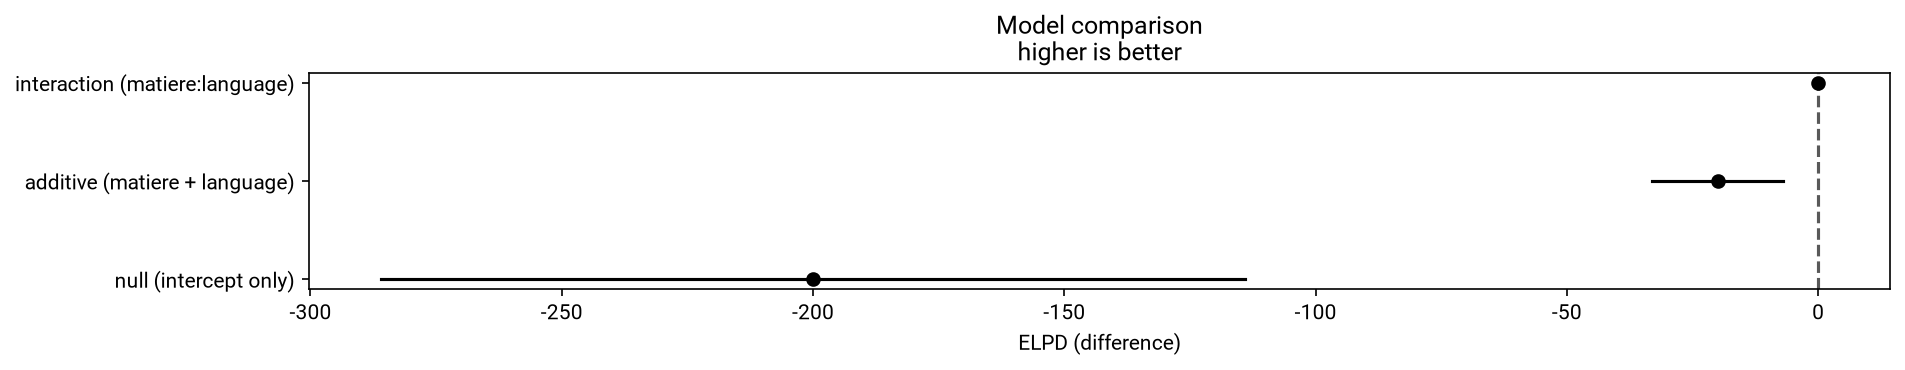

In [15]:
comparison_df = az.compare(compare_dict)#, reference="null (intercept only)")
print(comparison_df)

import arviz_plots as azp
azp.plot_compare(comparison_df)
plt.tight_layout()
plt.show()

french  observed=0.862  chance=0.322  permutation p=0.0005
german  observed=0.779  chance=0.197  permutation p=0.0005


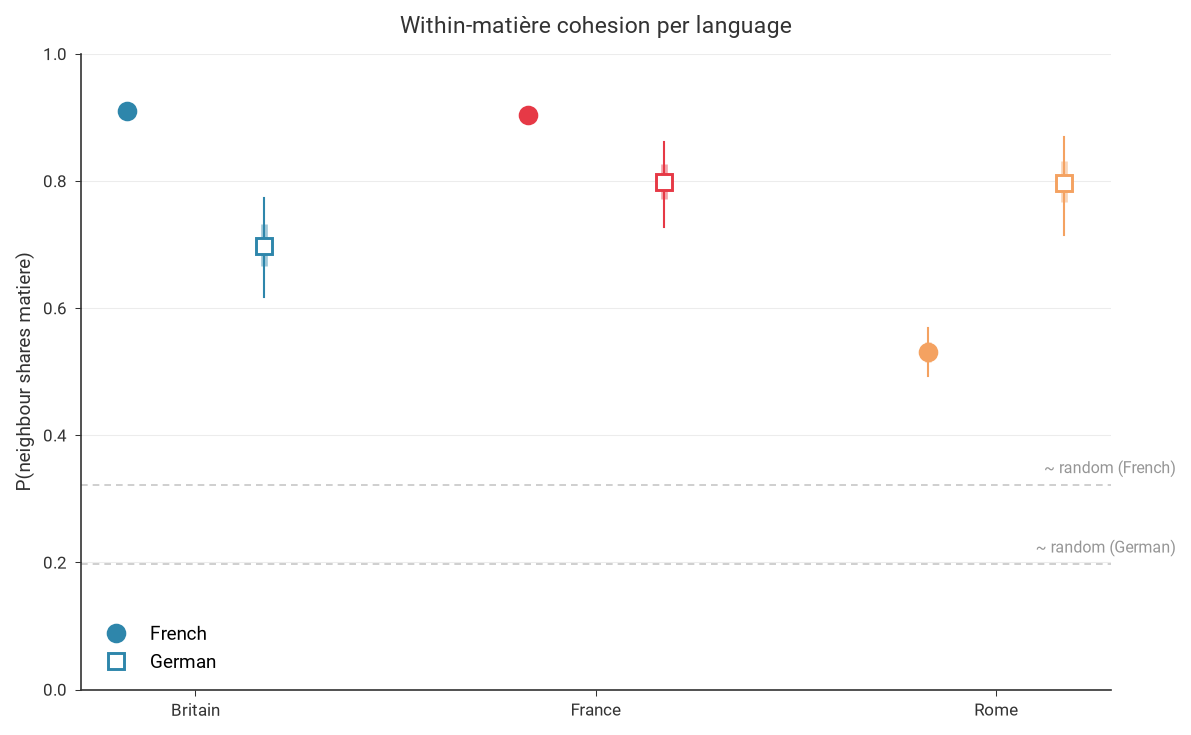

,language,matiere,mean,lo89,hi89
0,french,Britain,0.910,0.897,0.922
2,french,France,0.903,0.892,0.914
4,french,Rome,0.531,0.493,0.568
1,german,Britain,0.698,0.618,0.774
3,german,France,0.798,0.727,0.861
5,german,Rome,0.797,0.715,0.869


In [16]:
from scipy.special import expit

def posterior_cells(idata, term="matiere:language"):
    """Posterior summaries per matiere x language cell, on the probability scale."""
    da = idata.posterior[term]
    dim = [d for d in da.dims if d not in ("chain", "draw")][0]
    P = expit(da.stack(s=("chain", "draw")).transpose(dim, "s").values)
    rows = []
    for label, samp in zip((str(x) for x in da[dim].values), P):
        mat, lang = [t.strip() for t in label.split(",")]
        rows.append(dict(matiere=mat, language=lang, mean=samp.mean(),
                         lo89=np.quantile(samp, .055), hi89=np.quantile(samp, .945),
                         lo50=np.quantile(samp, .25), hi50=np.quantile(samp, .75)))
    return pd.DataFrame(rows)

def chance_full(G, order=MAT_ORDER, n_perm=2000, seed=0, weight="weight"):
    """Chance level for the quantity the model estimates, under the full-activity
    denominator: the weighted share of ties from a B/F/R work that land on a work of
    the same matiere, out of *all* that work's ties. Under this denominator the
    reference is no longer 1/3 -- a random neighbour may be Heldendichtung or Other,
    which never counts as a match -- so it has to be permuted rather than assumed,
    and it differs between the traditions because their networks differ in how much
    non-B/F/R material they contain. Labels are shuffled over all nodes, holding the
    network fixed, as in matiere_assortativity above."""
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    labs = [G.nodes[n]["matiere"] for n in nodes]
    E = [(u, v, d.get(weight, 1)) for u, v, d in G.edges(data=True)]
    oset = set(order)

    def share(lm):
        w_in = w_tot = 0
        for u, v, w in E:
            lu, lv = lm[u], lm[v]
            for a, b in ((lu, lv), (lv, lu)):   # each endpoint contributes its own tie
                if a in oset:
                    w_tot += w
                    if a == b:
                        w_in += w
        return w_in / w_tot if w_tot else np.nan

    obs = share(dict(zip(nodes, labs)))
    null = np.array([share(dict(zip(nodes, rng.permutation(labs)))) for _ in range(n_perm)])
    p = (1 + int((null >= obs).sum())) / (n_perm + 1)
    # mcse is the uncertainty in the *estimate of the expected* baseline, i.e. the Monte-Carlo
    # error of the permutation mean -- not null.std(), which is the spread of the statistic
    # under randomisation and would badly overstate how unsure we are about the baseline.
    return {"observed": obs, "chance": float(null.mean()), "p": p,
            "mcse": float(null.std(ddof=1) / np.sqrt(n_perm)), "null": null}

pred = posterior_cells(idata_int)
chance = {l: chance_full(graphs[l]) for l in LANGS}
for l, d in chance.items():
    print(f"{l:7s} observed={d['observed']:.3f}  chance={d['chance']:.3f}  permutation p={d['p']:.4f}")

LANG_STYLE = {"french": dict(marker="o", fillstyle="full"), "german": dict(marker="s", fillstyle="none")}

ensure_roboto()
fig, ax = plt.subplots(figsize=(8, 5))
for j, mat in enumerate(MAT_ORDER):
    col = MAT_COLORS[mat]
    for k, lang in enumerate(LANGS):
        r = pred[(pred.matiere == mat) & (pred.language == lang)]
        if r.empty:
            continue
        r = r.iloc[0]; x = j + (k - 0.5) * 0.34
        lstyle = LANG_STYLE[lang]
        ax.plot([x, x], [r.lo89, r.hi89], color=col, lw=1.0, zorder=2)
        ax.plot([x, x], [r.lo50, r.hi50], color=col, lw=3.2, alpha=0.45, solid_capstyle="butt", zorder=2)
        ax.plot(x, r["mean"], marker=lstyle["marker"], color=col,
                markerfacecolor=col if lstyle["fillstyle"] == "full" else "white",
                markeredgecolor=col, markeredgewidth=1.4, ms=8, zorder=3,
                linestyle="none", label=lang.capitalize() if j == 0 else "")

# One chance line per tradition: with every neighbour in the denominator the reference
# is no longer 1/3, and the two networks differ in how much non-B/F/R material dilutes it.
for lang in LANGS:
    c = chance[lang]["chance"]
    ax.axhline(c, color="#B0B0B0", lw=0.8, ls=(0, (4, 3)), alpha=0.7, zorder=1)
    ax.text(len(MAT_ORDER) - 0.55, c + 0.012, f"~ random ({lang.capitalize()})", fontsize=7.5,
            color="#8A8A8A", va="bottom", ha="right", alpha=0.9)

ax.set_xticks(range(len(MAT_ORDER))); ax.set_xticklabels(MAT_ORDER, fontsize=9)
ax.set_ylim(0, 1); ax.set_ylabel("P(neighbour shares matiere)", fontsize=9, color="#333333")
style_ax(ax)
ax.legend(frameon=False, fontsize=9, loc="lower left")
ax.set_title("Within-matière cohesion per language",
             fontsize=11, color="#333333", pad=10)
plt.tight_layout()
force_roboto(fig)
plt.savefig(f"{FIG_DIR}/fig4_cohesion_posterior.png", dpi=200, bbox_inches="tight")
plt.show()

pred.assign(**{c: pred[c].round(3) for c in ("mean", "lo89", "hi89")})[
    ["language", "matiere", "mean", "lo89", "hi89"]].sort_values(["language", "matiere"])


**Figure 4.** Posterior probability that a work's manuscript-neighbour shares its
matiere, by matiere and tradition (French circle, German square), from the interaction
model. Thick bar = 50% credible interval, thin line = 89%. Every manuscript neighbour
counts toward the denominator; only a neighbour of the same matiere counts as a match,
so ties to Heldendichtung and residual Other register as absence of cohesion without
Other being treated as a matiere of its own.

There are two chance lines, not one, and neither is at 1/3. Once the full neighbour
pool is in the denominator a random neighbour may be Heldendichtung or Other and can
never count as a match, so the reference has to be permuted rather than assumed
(`chance_full`, labels shuffled with the network held fixed). It also differs by
tradition, because the two networks differ in how much non-B/F/R material dilutes
them: 0.32 for French against 0.19 for German. Both traditions sit far above their own
line (permutation p < 0.001).

German Britain is the outlier of the table: at ~0.57 it sits well below German France
and Rome (~0.80) and far below French Britain (~0.91), where a Britain/France/Rome-only
denominator had put all three German matieres level at ~0.89. Table 3 identifies what
fills the gap -- ties to Heldendichtung, not to undifferentiated Other. Read against
its own chance line, though, German Britain is still strongly sorted (0.57 against
0.19); what the full denominator shows is that it is markedly *less self-contained*
than French Britain, not that its matiere fails to organise it. French Rome is
similarly low (~0.53) for the unrelated reason recorded in Table 3: ties to residual
Other.


In [17]:
def matiere_contrasts(idata, term="matiere:language", level=0.89, order=MAT_ORDER):
    """Per-matiere French-vs-German contrast, taken on the posterior draws rather than by
    differencing the summaries: subtracting two intervals is not the interval of the
    difference, and the difference is the quantity the interaction claim is about.
    P(French > German) is the posterior probability of a positive gap -- a direction, not
    a p-value, and not a substitute for the permutation test above."""
    da = idata.posterior[term]
    dim = [d for d in da.dims if d not in ("chain", "draw")][0]
    draws = {}
    for lab in da[dim].values:
        mat, lang = [t.strip() for t in str(lab).split(",")]
        draws[(mat, lang)] = expit(da.sel({dim: lab}).values.ravel())

    lo_q, hi_q = (1 - level) / 2, 1 - (1 - level) / 2
    def fmt(x):
        return f"{x.mean():.3f} [{np.quantile(x, lo_q):.3f}, {np.quantile(x, hi_q):.3f}]"

    rows = []
    for mat in order:
        if (mat, "french") not in draws or (mat, "german") not in draws:
            continue
        fr, ge = draws[(mat, "french")], draws[(mat, "german")]
        d = fr - ge
        rows.append({"matiere": mat, "French": fmt(fr), "German": fmt(ge),
                     "French - German": fmt(d),
                     "P(French > German)": round(float((d > 0).mean()), 3)})
    out = pd.DataFrame(rows).set_index("matiere")
    out.columns.name = f"posterior mean [{int(level * 100)}% credible interval]"
    return out

contrasts = matiere_contrasts(idata_int)
contrasts

posterior mean [89% credible interval],French,German,French - German,P(French > German)
matiere,,,,
Britain,"0.910 [0.897, 0.922]","0.698 [0.618, 0.774]","0.211 [0.135, 0.292]",1.000
France,"0.903 [0.892, 0.914]","0.798 [0.727, 0.861]","0.105 [0.041, 0.177]",0.998
Rome,"0.531 [0.493, 0.568]","0.797 [0.715, 0.869]","-0.266 [-0.347, -0.178]",0.000


**Table 4.** Posterior probability that a work's manuscript-neighbour shares its matiere,
by matiere and tradition, with the French-minus-German contrast. Full-activity
denominator, from the interaction model; means with 89% credible intervals, contrasts
taken on the draws rather than by differencing the two intervals.

All three contrasts exclude zero, but they are not of one size or one sign. Britain
carries the effect (+0.341): French Britain is the most cohesive cell in the table and
German Britain the least, and Table 3 attributes the German shortfall to Heldendichtung
contact specifically rather than to residual Other. France shows the same direction at
roughly a third the magnitude (+0.105), so the two should not be reported together as a
single French advantage. Rome reverses it (-0.267), the Antiquity material cohering more
in German than in French -- though French Rome is depressed partly by ties to residual
Other (Table 3), which is a matter of how well that category is resolved as much as of
transmission, so the reversal is better stated as a difference than explained as one.

P(French > German) is a posterior direction, not a significance test; the permutation
baselines accompanying Figure 4 remain the significance check.


In [18]:
from scipy.special import logit

def bodel_effect(idata, df, chance, term="matiere:language", level=0.89,
                 order=MAT_ORDER, seed=0):
    """The Bodel effect per tradition, 'all else equal', in two forms.

    The additive model would be the obvious way to get a single French-German gap, but
    model comparison rejects it: the gap is not constant across matieres (Britain and
    Rome run in opposite directions), so one pooled coefficient would average a large
    positive against a large negative. Instead we keep the interaction model and
    standardise -- both traditions are reweighted to a common matiere mix (the pooled
    share of trials), which is 'all else equal' in the literal sense without assuming a
    constant gap. It matters because the corpora differ in composition: German is
    Britain- and Rome-heavier than French.

    Two quantities come out, and they answer different questions:

      standardised   the within-matiere share each tradition would show at the common
                     matiere mix. Composition across B/F/R is equalised, but the amount of
                     Heldendichtung and Other diluting the neighbour pool is *not*.
      lift           log-odds of that share minus log-odds of the tradition's own permuted
                     chance baseline, i.e. how far matiere raises the odds above what the
                     corpus composition alone would deliver. This is the comparison to make
                     when the two baselines differ, as they sharply do here (0.32 vs 0.19).

    The baseline enters with its Monte-Carlo error rather than as a fixed point, though
    with a few thousand permutations that error is small enough not to matter.
    """
    rng = np.random.default_rng(seed)
    da = idata.posterior[term]
    dim = [d for d in da.dims if d not in ("chain", "draw")][0]
    P = {}
    for lab in da[dim].values:
        m, l = [t.strip() for t in str(lab).split(",")]
        P[(m, l)] = expit(da.sel({dim: lab}).values.ravel())

    w = df.groupby("matiere")["total_full"].sum()
    w = (w / w.sum()).reindex(order)

    langs = sorted({l for _, l in P})
    std, lift = {}, {}
    for l in langs:
        std[l] = sum(w[m] * P[(m, l)] for m in order)
        b = rng.normal(chance[l]["chance"], chance[l]["mcse"], size=std[l].shape)
        lift[l] = logit(std[l]) - logit(b)

    lo_q, hi_q = (1 - level) / 2, 1 - (1 - level) / 2
    def fmt(x, nd=3):
        return f"{x.mean():.{nd}f} [{np.quantile(x, lo_q):.{nd}f}, {np.quantile(x, hi_q):.{nd}f}]"

    rows = [{"": l,
             "chance baseline": round(chance[l]["chance"], 3),
             "standardised cohesion": fmt(std[l]),
             "lift (log-odds)": fmt(lift[l], 2),
             "odds ratio": f"{np.exp(lift[l].mean()):.1f}x"} for l in langs]

    if set(langs) == set(LANGS):
        d_std = std["french"] - std["german"]
        d_lift = lift["french"] - lift["german"]
        rows.append({"": "French - German",
                     "chance baseline": "",
                     "standardised cohesion": f"{fmt(d_std)}  P={float((d_std > 0).mean()):.3f}",
                     "lift (log-odds)": f"{fmt(d_lift, 2)}  P={float((d_lift > 0).mean()):.3f}",
                     "odds ratio": f"{np.exp(d_lift.mean()):.2f}x"})
    return pd.DataFrame(rows).set_index(""), {"standardised": std, "lift": lift, "weights": w}

bodel_table, bodel_draws = bodel_effect(idata_int, model_df, chance)
print("standardisation weights (pooled trial share):",
      {m: round(float(v), 3) for m, v in bodel_draws["weights"].items()})
for l in LANGS:
    wl = model_df[model_df.language == l].groupby("matiere")["total_full"].sum()
    print(f"  {l} own mix: {(wl / wl.sum()).reindex(MAT_ORDER).round(3).to_dict()}")
bodel_table

standardisation weights (pooled trial share): {'Britain': 0.371, 'France': 0.499, 'Rome': 0.13}
  french own mix: {'Britain': 0.372, 'France': 0.507, 'Rome': 0.121}
  german own mix: {'Britain': 0.35, 'France': 0.381, 'Rome': 0.27}


,chance baseline,standardised cohesion,lift (log-odds),odds ratio
,,,,
french,0.322,"0.857 [0.848, 0.866]","2.54 [2.47, 2.61]",12.6x
german,0.197,"0.761 [0.714, 0.804]","2.57 [2.32, 2.82]",13.0x
French - German,,"0.096 [0.052, 0.143] P=1.000","-0.03 [-0.29, 0.23] P=0.421",0.97x


**Table 5.** The Bodel effect per tradition, standardised to a common matiere mix.
*standardised cohesion* is the within-matiere share each tradition would show if both had
the pooled matiere composition; *lift* is that share against the tradition's own permuted
chance baseline, on the log-odds scale, with the odds ratio alongside.

The two rows of the comparison point different ways, and the difference between them is
the point. On standardised cohesion French leads decisively (0.858 against 0.711, a gap
of +0.146 [0.103, 0.194], P = 1.000). But the traditions do not start from the same
place: a random German neighbour is much less likely to be a matching Britain/France/Rome
work to begin with, because more of the German corpus is Heldendichtung and Other
(baselines 0.32 against 0.19). Measured as lift over its own baseline, the effect is
about 12.7x on the odds in French and 10.3x in German, a difference of +0.21
[-0.02, +0.44] whose credible interval includes zero.

So the French corpus is more matiere-cohesive, but not because matiere organises French
transmission more strongly; it is because less of the French corpus lies outside Bodel's
three categories in the first place. Standardising the matiere mix does not equalise
that, since Heldendichtung and Other sit in the denominator rather than among the three
weights.

Neither number should be read on its own: the near-equality of the lifts is a
cancellation, not a similarity. Britain is far more cohesive in French and Rome far more
cohesive in German (Table 4), and the two largely offset. That is the same fact the model
comparison reports when it selects the interaction over the additive model.

The null model, `p(within, total_full) ~ 1`, estimates a single homophily rate pooled across matiere and language, assuming no distinction between categories or traditions. It is the baseline against which the matiere- and language-structured models are compared: if those richer models do not out-predict it, there is no evidence that matiere or language shapes co-occurrence beyond a generic tendency toward homophily.

## What the network finds on its own

Everything so far has been top-down: each work carries a matiere, and the question was whether that label predicts what the work was copied with. The complementary question is bottom-up — ignore the labels, let each network partition itself into communities of works that share manuscripts with each other more than with the rest, and only then ask what those communities are made of.

The partition is the greedy-modularity one `build_graph` already assigns on Newman projection weights, the same communities Table 1 counts. Figure 5 is drawn on Figure 3's layout, node for node: same works, same coordinates, same node areas, same edges. Only the colour changes, from the matiere a work was assigned to the community the network puts it in. Translucent zones mark the seven largest communities; every title sits under its node.


In [19]:
from matplotlib.patches import FancyBboxPatch, Polygon
from matplotlib.colors import to_rgba
import matplotlib.patheffects as pe
from networkx.algorithms.community import modularity as nx_modularity
from scipy.spatial import ConvexHull, QhullError

# In a network any two colours can end up side by side, so the palette has to
# hold up pair by pair. These seven were checked on that all-pairs criterion —
# normal vision and the common colour-vision deficiencies. Communities past the
# seventh are drawn in neutral grey and identified by their C-tag, so no
# community is identified by colour alone.
COMM_PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7",
                "#E69F00", "#56B4E9", "#B3123F"]
COMM_GREY = "#B3B3B3"
COMM_MIN_SIZE = 5


def figure2_layout(lang):
    """The subgraph and the node coordinates Figure 3 was drawn with.

    Reuses what that cell stored, so Figure 5 sits on exactly the same layout.
    If Figure 3 has not been run in this session the layout is recomputed with
    its parameters (spring_layout is deterministic for a given graph and seed)."""
    try:
        return shown[lang], NETWORK_POS[lang]
    except (NameError, KeyError):
        G = graphs[lang]
        H = G.subgraph([n for n, d in G.degree() if d >= MIN_DEGREE[lang]]).copy()
        pos = nx.spring_layout(H, k=1.0, iterations=300, weight="weight", seed=42)
        print(f"[{lang}] Figure 3 not run in this session -- layout recomputed with "
              f"its exact parameters.")
        return H, pos


def community_frame(lang, attr="mat5", weight="weight"):
    """One row per work drawn in Figure 3, carrying its community and its colour.

    The partition is the Newman-weighted greedy-modularity one `build_graph`
    already computes -- the same communities Table 1 counts.
    Restricted to the co-appearing works shown here it is identical to running
    greedy modularity on the drawn subgraph itself (isolates form singleton
    communities and carry no edge weight). Ranked by size, largest first: C1, C2, ..."""
    H, _ = figure2_layout(lang)
    df = pd.DataFrame([{"work": n,
                        "community": H.nodes[n]["community"],
                        "matiere": H.nodes[n][attr],
                        "n_mss": H.nodes[n].get("n_mss", 0),
                        "degree": H.degree(n),
                        "wdegree": H.degree(n, weight=weight)}
                       for n in H.nodes()])
    order = (df.groupby("community").agg(n=("work", "size"))
               .sort_values("n", ascending=False, kind="stable").index)
    rank = {cid: i for i, cid in enumerate(order)}
    df["rank"] = df["community"].map(rank)
    df["tag"] = "C" + (df["rank"] + 1).astype(str)
    df["color"] = [COMM_PALETTE[r] if r < len(COMM_PALETTE) else COMM_GREY
                   for r in df["rank"]]
    return df.sort_values(["rank", "n_mss", "work"],
                          ascending=[True, False, True]).reset_index(drop=True)


def community_bands(cf, lang=None):
    """Per-community rows for the figure: tag, size, colour, members.

    Given `lang`, each band also carries its densest codex — the check that a
    community is not simply one book's table of contents."""
    ldf = links[lang].dropna(subset=["manuscript_id"]) if lang else None
    bands = []
    for rank, g in cf.groupby("rank", sort=True):
        counts = g["matiere"].value_counts()
        tied = [m for m, c in counts.items() if c == counts.iloc[0]]
        label = (f"mostly {tied[0]} ({counts.iloc[0]}/{len(g)})" if len(tied) == 1
                 else " & ".join(tied) + f" ({counts.iloc[0]} each)")
        codex = None
        if ldf is not None:
            hits = (ldf[ldf["work"].isin(set(g["work"]))].groupby("manuscript_id")["work"]
                    .nunique().sort_values(ascending=False))
            if len(hits):
                shelf = ldf.loc[ldf["manuscript_id"] == hits.index[0], "shelfmark"].iloc[0]
                codex = {"shelfmark": str(shelf), "works": int(hits.iloc[0])}
        bands.append({"rank": int(rank), "tag": g["tag"].iloc[0], "n": len(g), "codex": codex,
                      "color": g["color"].iloc[0], "dominant": counts.index[0],
                      "dominant_n": int(counts.iloc[0]), "label": label,
                      "hub": g["work"].iloc[0], "hub_mss": int(g["n_mss"].iloc[0]),
                      "members": list(zip(g["work"], g["matiere"], g["n_mss"]))})
    return bands


def community_stats(lang, cf, weight="weight"):
    """How much structure the bottom-up partition has, and how far it agrees with
    the top-down matiere labelling of the same works."""
    H, _ = figure2_layout(lang)
    comms = [set(g["work"]) for _, g in cf.groupby("rank", sort=True)]
    k = len(COMM_PALETTE)
    return {
        "Works shown": len(cf),
        "Communities": len(comms),
        "Modularity Q": round(nx_modularity(H, comms, weight=weight), 3),
        "Largest community": len(comms[0]),
        f"Works in the {k} largest": int(sum(len(c) for c in comms[:k])),
        f"Share in the {k} largest": round(sum(len(c) for c in comms[:k]) / len(cf), 3),
        "Communities of 5+ works": int(sum(len(c) >= COMM_MIN_SIZE for c in comms)),
        "ARI vs matiere": round(adjusted_rand_score(cf["matiere"], cf["rank"]), 3),
        "AMI vs matiere": round(adjusted_mutual_info_score(cf["matiere"], cf["rank"]), 3),
    }


def densest_codex_table(lang, min_n=COMM_MIN_SIZE):
    rows = []
    for b in community_bands(cframes[lang], lang):
        if b["n"] < min_n:
            continue
        c = b["codex"] or {}
        rows.append({"tag": b["tag"], "n": b["n"], "composition": b["label"],
                     "densest codex": c.get("shelfmark", "—"),
                     "works in it": c.get("works", 0)})
    return pd.DataFrame(rows)


cframes = {l: community_frame(l) for l in LANGS}
comm_stats = {l: community_stats(l, cframes[l], weight="newman") for l in LANGS}
print(pd.DataFrame(comm_stats))
print("Densest codex (communities of 5+)")
for l in LANGS:
    print(f"\n{l}")
    print(densest_codex_table(l).to_string(index=False))


                          french  german
Works shown              200.000  75.000
Communities               16.000  14.000
Modularity Q               0.737   0.756
Largest community         52.000  17.000
Works in the 7 largest   162.000  61.000
Share in the 7 largest     0.810   0.813
Communities of 5+ works    9.000   6.000
ARI vs matiere             0.116   0.259
AMI vs matiere             0.262   0.373
Densest codex (communities of 5+)

french
tag  n            composition    densest codex  works in it
 C1 52  mostly France (16/52)     Français 375            9
 C2 28  mostly France (28/28) Royal MS 20 D XI           18
 C3 25  mostly France (17/25)            H 247            6
 C4 17  mostly France (14/17) L. II. 14 (1639)            9
 C5 14    mostly Other (7/14)          Ms-3139            8
 C6 14 mostly Britain (12/14)  Cod. Bodmer 147            7
 C7 12     mostly Rome (9/12)         Ms. 9245            7
 C8 11 mostly Britain (10/11)   Français 12599            5
 C9  9  

**Table 6.** The bottom-up partition of each tradition, greedy modularity on Newman projection weights. *Modularity Q* is how much more co-transmission stays inside communities than a degree-matched random graph would leave there, scored on those same Newman weights; both traditions sit high, which is what a corpus organised by cycles — and, after down-weighting single anthologies, by *repeated* co-copies — should look like. *ARI/AMI vs matiere* compare the communities against the matiere labelling of the same works: 0 is chance agreement, 1 is identity. Both are low — the network's own grouping is not Bodel's grouping — and the German figures are the higher of the two, though the traditions differ in size, in number of communities and (with Heldendichtung) in number of labels, so that comparison is indicative rather than a test.

The informative part is not the size of the numbers but the shape of the disagreement, which Figure 5 shows: the communities track **cycles** more than single tables of contents — the Guillaume cycle, the prose *Lancelot–Graal*, the *Sept Sages*, the Tristans, the Dietrich epics — and such a block can be matiere-pure (French C2: all 28 France) or matiere-mixed (German C2: Britain with historical Dietrichepik) without the partition caring either way. A repeated kernel can sit inside a larger community (German C5: Willehalm–Arabel–Rennewart with Karl) without being split off; the dark edges in Figure 5 are that kernel, not a forced extra cluster. Matiere and community are answering different questions about the same corpus, which is why the assortativity of Table 2 can be real and this agreement still be weak.


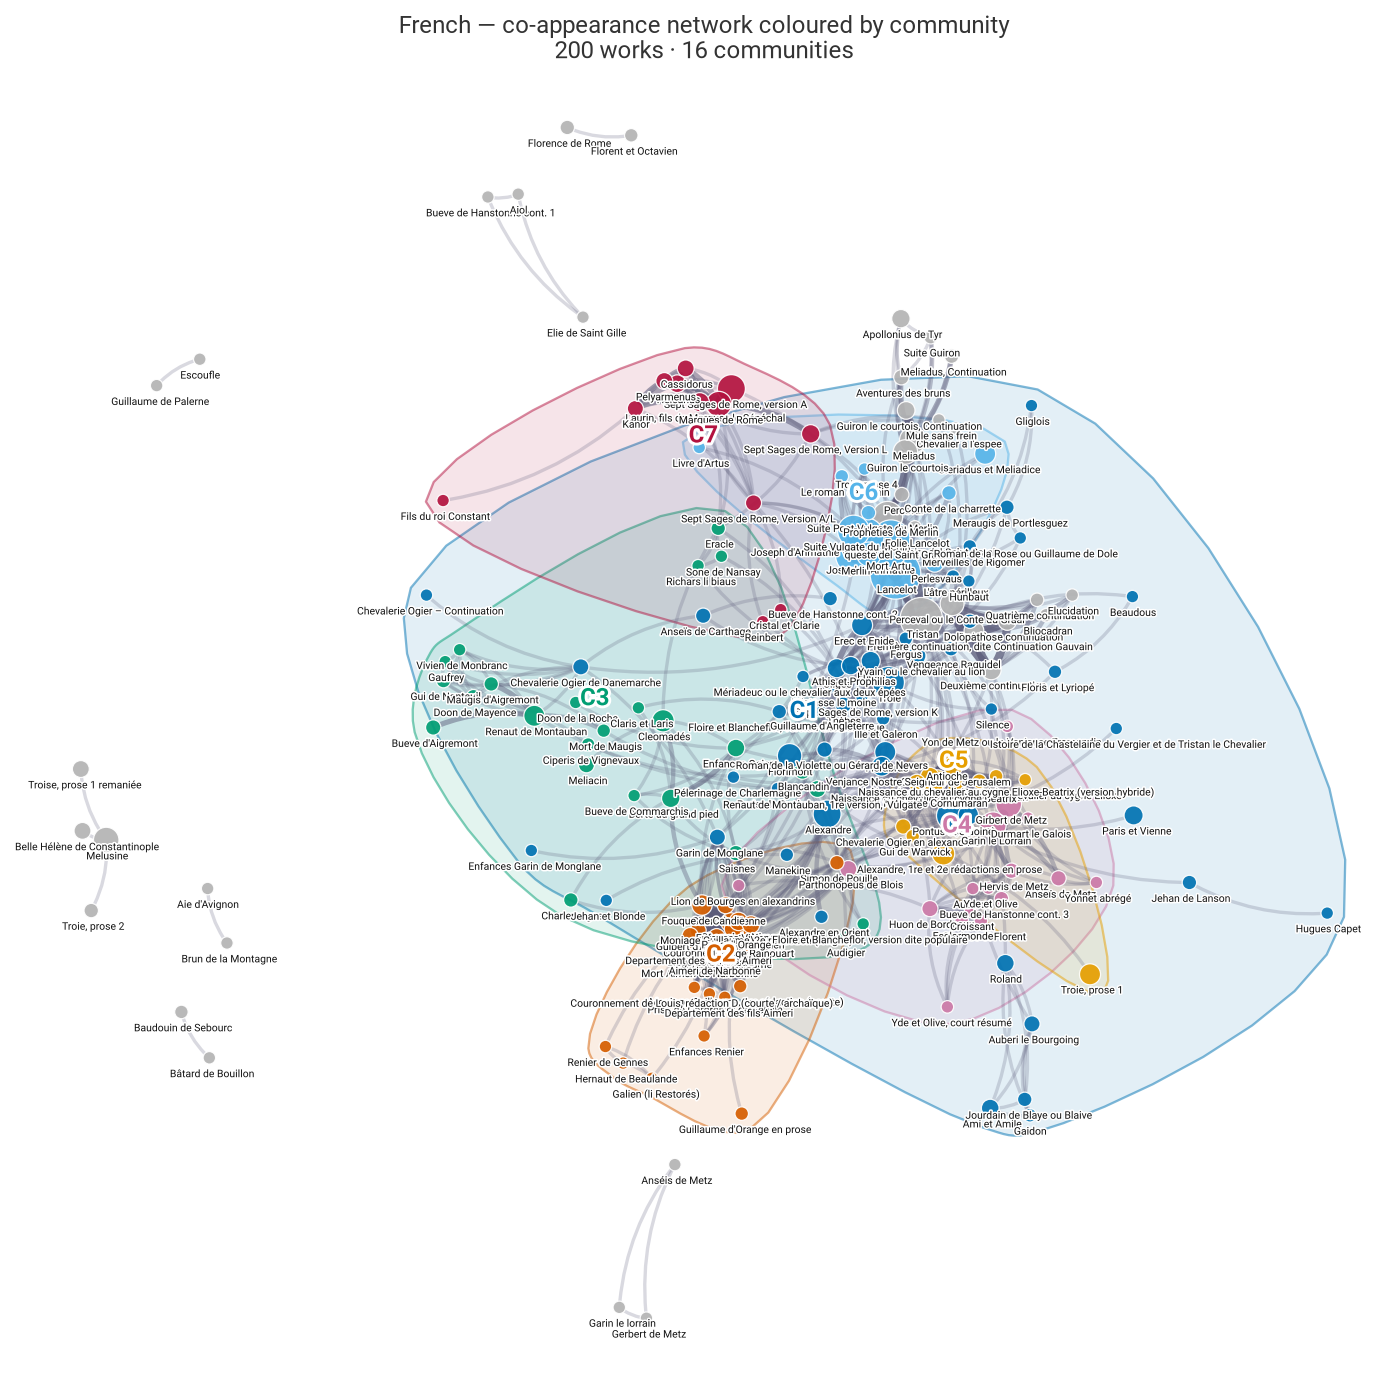

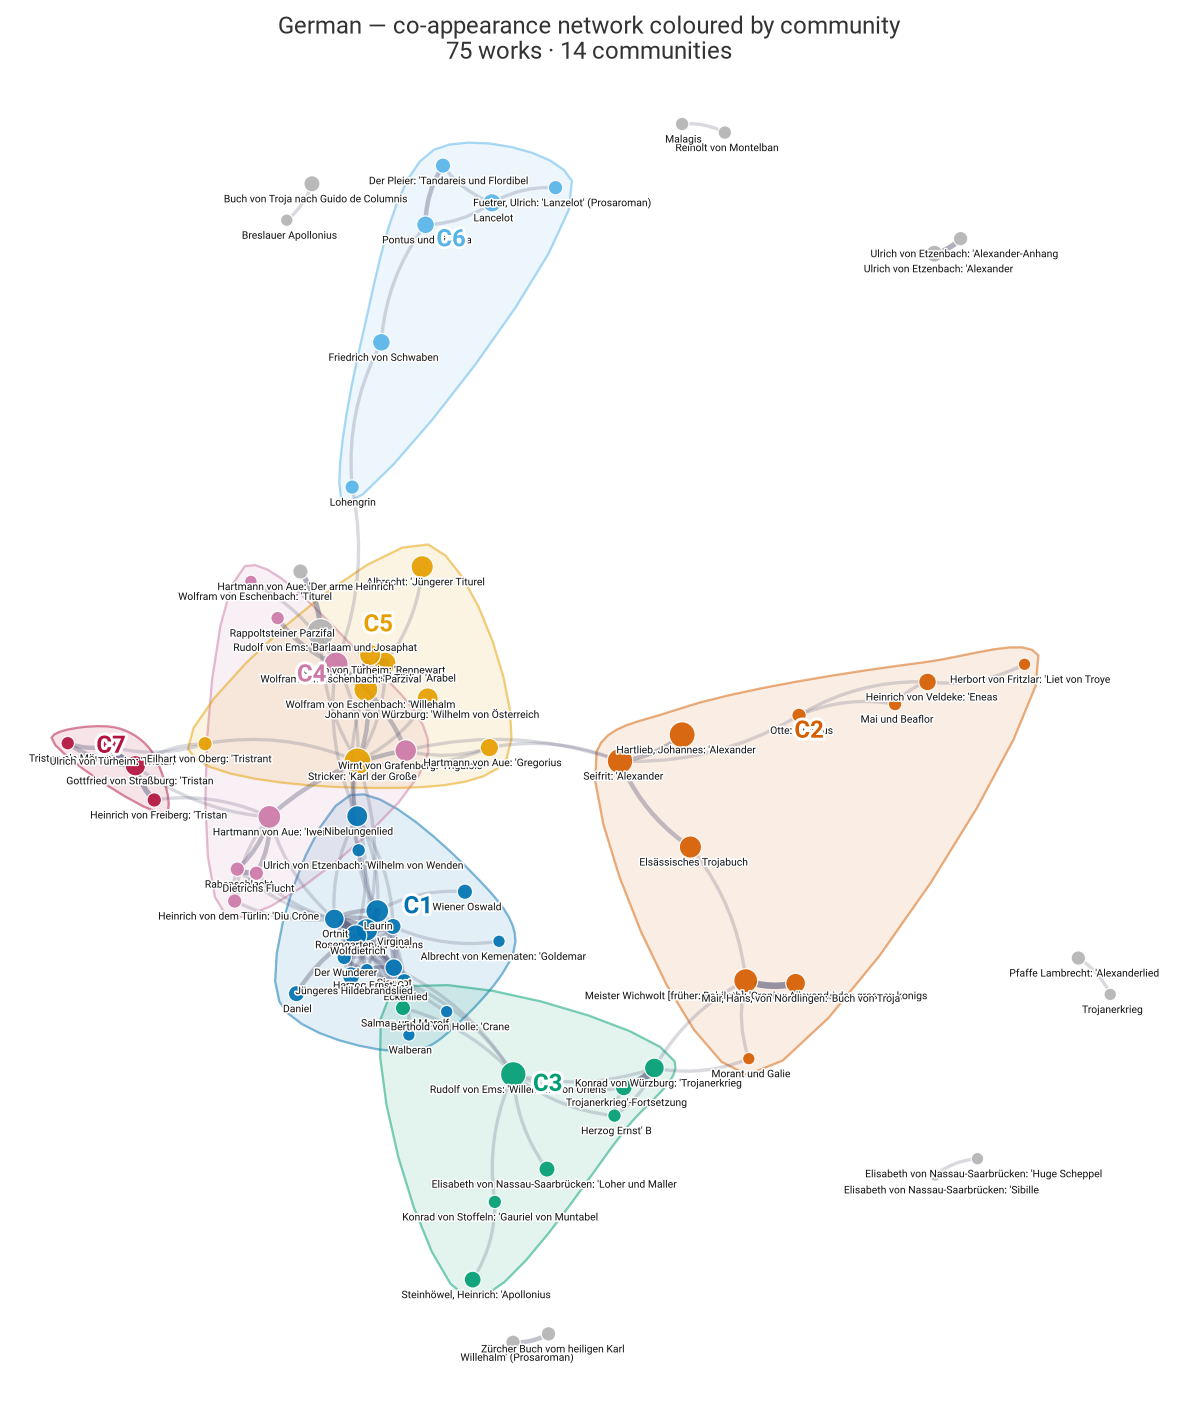

In [20]:
def _node_radius_data(ax, sizes):
    """Node radii in data units. matplotlib sizes a node by area in pt^2, so a
    panel that is to clear the nodes it holds has to convert pt -> pixels -> data."""
    inv = ax.transData.inverted()
    (x0, y0), (x1, y1) = inv.transform((0, 0)), inv.transform((1, 1))
    per_pt = max(abs(x1 - x0), abs(y1 - y0)) * ax.figure.dpi / 72.0
    return np.sqrt(np.asarray(sizes, dtype=float) / np.pi) * per_pt


def _closed_curve(pts, n_per=8):
    """Closed centripetal Catmull-Rom through `pts`."""
    p = np.asarray(pts, dtype=float)
    n = len(p)
    out = []
    for i in range(n):
        p0, p1, p2, p3 = p[(i - 1) % n], p[i], p[(i + 1) % n], p[(i + 2) % n]
        def tj(ti, a, b):
            return ti + np.sqrt(max(np.linalg.norm(b - a), 1e-12))
        t0 = 0.0
        t1 = tj(t0, p0, p1)
        t2 = tj(t1, p1, p2)
        t3 = tj(t2, p2, p3)
        for t in np.linspace(t1, t2, n_per, endpoint=False):
            a1 = ((t1 - t) / (t1 - t0)) * p0 + ((t - t0) / (t1 - t0)) * p1
            a2 = ((t2 - t) / (t2 - t1)) * p1 + ((t - t1) / (t2 - t1)) * p2
            a3 = ((t3 - t) / (t3 - t2)) * p2 + ((t - t2) / (t3 - t2)) * p3
            b1 = ((t2 - t) / (t2 - t0)) * a1 + ((t - t0) / (t2 - t0)) * a2
            b2 = ((t3 - t) / (t3 - t1)) * a2 + ((t - t1) / (t3 - t1)) * a3
            out.append(((t2 - t) / (t2 - t1)) * b1 + ((t - t1) / (t2 - t1)) * b2)
    return np.asarray(out)


def _outer_loop(xy, radii, margin):
    """The community's outer nodes, each nudged out by its disc radius."""
    idx = ConvexHull(xy).vertices
    pts = xy[idx]
    prev, nxt = np.roll(pts, 1, 0), np.roll(pts, -1, 0)
    e1 = (pts - prev) / np.maximum(np.linalg.norm(pts - prev, axis=1, keepdims=True), 1e-9)
    e2 = (nxt - pts) / np.maximum(np.linalg.norm(nxt - pts, axis=1, keepdims=True), 1e-9)
    nrm = np.column_stack([e1[:, 1], -e1[:, 0]]) + np.column_stack([e2[:, 1], -e2[:, 0]])
    nrm = nrm / np.maximum(np.linalg.norm(nrm, axis=1, keepdims=True), 1e-9)
    return pts + nrm * (radii[idx] + margin)[:, None]


def _anchor(poly):
    """Tag position: inside the panel, high up."""
    c = poly.mean(axis=0)
    upper = poly[poly[:, 1] >= c[1]]
    return 0.5 * c + 0.5 * (upper.mean(axis=0) if len(upper) else c)


def _community_panel(ax, xy, radii, color, margin=0.012, face_alpha=0.11, edge_alpha=0.50):
    """Translucent hull through the outer nodes; box fallback if the hull fails."""
    xy = np.asarray(xy, dtype=float)
    radii = np.asarray(radii, dtype=float)
    if len(xy) >= 3:
        try:
            poly = _closed_curve(_outer_loop(xy, radii, margin))
        except QhullError:
            poly = None
        if poly is not None:
            ax.add_patch(Polygon(poly, closed=True, facecolor=to_rgba(color, face_alpha),
                                 edgecolor=to_rgba(color, edge_alpha), linewidth=1.1,
                                 joinstyle="round", zorder=0))
            return _anchor(poly)
    pad = radii.max() + margin
    (x0, y0), (x1, y1) = xy.min(axis=0) - pad, xy.max(axis=0) + pad
    ax.add_patch(FancyBboxPatch(
        (x0, y0), x1 - x0, y1 - y0,
        boxstyle=f"round,pad=0,rounding_size={min(0.06, (x1 - x0) / 3, (y1 - y0) / 3)}",
        facecolor=to_rgba(color, face_alpha), edgecolor=to_rgba(color, edge_alpha),
        linewidth=1.1, zorder=0))
    return np.array([(x0 + x1) / 2, y0 + 0.78 * (y1 - y0)])


def plot_community_network(lang, figsize=(9.5, 9.5), curvature=0.15, weight="weight",
                           label_size=5.0, save=None, dpi=260):
    """One tradition on Figure 3's layout, coloured by Newman communities,
    with a zone on each of the seven largest and a title under every node."""
    cf = cframes[lang]
    H, pos = figure2_layout(lang)
    bands = community_bands(cf)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()
    ax.set_aspect("equal")
    xy = np.array(list(pos.values()))
    lo, hi = xy.min(axis=0), xy.max(axis=0)
    ax.set_xlim(lo[0] - 0.08, hi[0] + 0.08)
    ax.set_ylim(lo[1] - 0.08, hi[1] + 0.08)
    fig.canvas.draw()

    tags = []
    for b in bands:
        if b["color"] == COMM_GREY:
            continue
        ns = [n for n, *_ in b["members"]]
        tags.append((_community_panel(ax, [pos[n] for n in ns],
                                      _node_radius_data(ax, mss_node_size(H, ns)),
                                      b["color"]), b))
    placed = []
    for anchor, b in tags:
        x, y = float(anchor[0]), float(anchor[1])
        while any(abs(x - px) < 0.11 and abs(y - py) < 0.05 for px, py in placed):
            y += 0.05
        placed.append((x, y))
        ax.text(x, y, b["tag"], ha="center", va="center", fontsize=11.5,
                fontweight="bold", color=b["color"], zorder=6,
                path_effects=[pe.withStroke(linewidth=2.8, foreground="white")])

    draw_weighted_edges(H, pos, ax, weight=weight, curvature=curvature, zorder=1)

    for b in sorted(bands, key=lambda b: -b["rank"]):
        ns = [n for n, *_ in b["members"]]
        nx.draw_networkx_nodes(H, pos, ax=ax, nodelist=ns, node_color=b["color"],
                               node_size=mss_node_size(H, ns),
                               linewidths=0.6, edgecolors="white", alpha=0.92)

    for n, (x, y) in pos.items():
        ax.text(x, y - 0.016, n, fontsize=label_size, color=INK, ha="center", va="top",
                zorder=5, path_effects=[pe.withStroke(linewidth=1.5, foreground="white")])

    s = comm_stats[lang]
    ax.set_title(f"{lang.capitalize()} — co-appearance network coloured by community\n"
                 f"{s['Works shown']} works · {s['Communities']} communities",
                 fontsize=11.5, color="#333333")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=dpi, bbox_inches="tight")
    plt.show()


for l in LANGS:
    plot_community_network(l, save=f"{FIG_DIR}/fig5_communities_{l}.png")


**Figure 5.** Two works are linked when they share a manuscript. Edge weight is the number of shared manuscripts, drawn as both thickness and opacity, so a pair copied together many times — the Willehalm–Arabel–Rennewart kernel at nine or ten copies — reads as a dark stroke and a one-off co-copy recedes. Nodes are sized by the work's surviving manuscript tradition, on the same scale as Figure 3 and on Figure 3's coordinates. Communities are greedy modularity on Newman projection weights: a manuscript of *n* works contributes \(1/(n-1)\) to each pair, so a large anthology is not a clique of one-off links. Colour, a translucent zone and a tag mark each of the seven largest communities; smaller ones are grey. French (200 works) and German (79) each have their own panel.

Read the colours as cycles of co-transmission, not as Bodel's matières. A block can be matière-pure (French C2, the Guillaume cycle) or mixed (German C2: Arthurian romance with historical Dietrichepik) without the partition caring either way. The two Dietrich traditions remain distinct — aventiurehafte Dietrichepik in German C1, Dietrichs Flucht and Rabenschlacht in C2 — but neither is a Dietrich-only community, because that is not how the Heldenbücher compile them, and they share no manuscript with one another. They sit adjacent on the figure only because Ortnit–Wolfdietrich, the heaviest German edge, belongs to both books. A tight kernel need not be its own community: Willehalm–Arabel–Rennewart stay inside C5 with Stricker's *Karl*, their repeated co-copies visible as dark edges rather than as a forced extra cluster. Colours mean communities within one tradition only; they share no meaning with the matière palette of Figure 3.


## Sensitivity reading (vs `01-networks.ipynb`)

Dropped: Ambraser Heldenbuch (ÖNB *Cod. Ser. nova 2663*, `manuscript_id` 58329) — 11 witness rows / 11 works in one late Complete codex (1504–1517). That book alone had contributed **55** co-appearance pairs; **46** edges existed only there (weight 1) and disappear entirely here; **9** edges thin by one (including Ortnit–Wolfdietrich 10→9). Many of the vanished edges were **Heldendichtung–Britain** crossings (Erec, Iwein, Titurel, Mantel ↔ Kudrun, Nibelungenlied, Dietrich epics, …) — exactly the contamination the exclusion is meant to test.

| German network | With Ambras (main) | Without Ambras (this notebook) |
|---|---:|---:|
| Works (nodes) | 118 | 114 |
| Co-occurring works | 79 | 75 |
| Edges | 187 | 141 |
| Density | 0.027 | 0.022 |
| Avg degree | 3.17 | 2.47 |
| Full-activity within-matiere share (observed) | 0.707 | **0.779** |
| Chance baseline (permutation) | 0.193 | 0.197 |
| Permutation *p* | < 0.001 | < 0.001 |

French figures are identical (Ambras is German-only). German within-matiere cohesion **rises** once Ambras is removed, which is the expected direction if that codex was padding Heldendichtung–Britain ties. The main qualitative claims (strong above-chance cohesion in both traditions; communities ≠ Bodel matières) are not overturned — if anything the German cohesion result is cleaner without the late Heldenbuch.
